In [1]:
import os  # Interact with the operating system (file handling, paths, etc.)
import gc  # Manages garbage collection (memory cleanup)
import PIL  # Image processing library (Pillow)
import cv2  # OpenCV for image processing and computer vision
import uuid  # Generate unique identifiers (used for unique filenames)
import shutil  # High-level file operations (copying, moving, deleting)
import random  # Generate random numbers, shuffle data, and sampling
import glob as gb  # Pattern-based file searching (e.g., "*.jpg" for all images)
import numpy as np  # Numerical computing with arrays and matrices
import pandas as pd  # Data handling with structured DataFrames
import tensorflow as tf  # Deep learning framework for building models
import matplotlib.pyplot as plt  # Data visualization (plots, graphs, image display)
import random


from PIL import Image  # Handling and processing image files
from tqdm import tqdm  # Display progress bars for loops
from scipy.special import gamma  # Gamma function used in probability and statistics

import keras  # High-level neural network API within TensorFlow
from keras.optimizers import *  # Various optimizers (Adam, SGD, RMSprop, etc.)
from keras.regularizers import l1_l2  # Regularization techniques (L1/L2) to prevent overfitting
from keras.utils import to_categorical  # Converts class labels to one-hot encoding
from keras.callbacks import EarlyStopping  # Stops training early if validation loss increases
from keras.models import Sequential, Model  # Model architectures (Sequential = linear, Model = flexible)
from keras.layers import Dense, Dropout, Input  # Fully connected layers, dropout for regularization, input layer
from keras.layers import GlobalAveragePooling2D  # Replaces fully connected layers to reduce parameters
from keras.callbacks import LearningRateScheduler  # Dynamically adjust learning rate during training
from keras.layers import Conv2D, MaxPool2D, BatchNormalization  # CNN layers for feature extraction & normalization

from tensorflow.keras.metrics import *  # Model evaluation metrics (accuracy, precision, recall, etc.)
from tensorflow.keras.callbacks import *  # Various training callbacks (checkpointing, early stopping)
from tensorflow.keras.preprocessing.image import ImageDataGenerator  # Augments images (rotation, zoom, flip, etc.)

from sklearn.model_selection import train_test_split  # Splits data into training and testing sets
from sklearn.utils import shuffle  # Shuffles data to prevent learning order biases

2025-08-02 22:50:35.259442: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1754175035.503112      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1754175035.572787      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [2]:
path = "/kaggle/input/cbis-ddsm-breast-cancer-image-dataset"

for files in os.listdir(path):
    files_dir = os.path.join(path, files)

    if files == 'jpeg':   # to pass 6774 files 
        pass
    else:
        for file in os.listdir(files_dir):
            print(file)

#Looping through each file/Folder and Ignore the folder named 'jpeg' and loop through the remaining files.dicom_df = pd.read_csv("/kaggle/input/cbis-ddsm-breast-cancer-image-dataset/csv/dicom_info.csv")

dicom_info.csv
mass_case_description_train_set.csv
calc_case_description_train_set.csv
meta.csv
calc_case_description_test_set.csv
mass_case_description_test_set.csv


In [3]:
dicom_df = pd.read_csv("/kaggle/input/cbis-ddsm-breast-cancer-image-dataset/csv/dicom_info.csv")
dicom_df.head(3)

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pan

,file_path,image_path,AccessionNumber,BitsAllocated,BitsStored,BodyPartExamined,Columns,ContentDate,ContentTime,ConversionType,...,SecondaryCaptureDeviceManufacturerModelName,SeriesDescription,SeriesInstanceUID,SeriesNumber,SmallestImagePixelValue,SpecificCharacterSet,StudyDate,StudyID,StudyInstanceUID,StudyTime
0,CBIS-DDSM/dicom/1.3.6.1.4.1.9590.100.1.2.12930...,CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.129308...,NaN,16,16,BREAST,351,20160426,131732.685,WSD,...,MATLAB,cropped images,1.3.6.1.4.1.9590.100.1.2.129308726812851964007...,1,23078,ISO_IR 100,20160720.0,DDSM,1.3.6.1.4.1.9590.100.1.2.271867287611061855725...,214951.0
1,CBIS-DDSM/dicom/1.3.6.1.4.1.9590.100.1.2.24838...,CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.248386...,NaN,16,16,BREAST,3526,20160426,143829.101,WSD,...,MATLAB,full mammogram images,1.3.6.1.4.1.9590.100.1.2.248386742010678582309...,1,0,ISO_IR 100,20160720.0,DDSM,1.3.6.1.4.1.9590.100.1.2.161516517311681906612...,193426.0
2,CBIS-DDSM/dicom/1.3.6.1.4.1.9590.100.1.2.26721...,CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.267213...,NaN,16,16,BREAST,1546,20160503,111956.298,WSD,...,MATLAB,full mammogram images,1.3.6.1.4.1.9590.100.1.2.267213171011171858918...,1,0,ISO_IR 100,20160807.0,DDSM,1.3.6.1.4.1.9590.100.1.2.291043622711253836701...,161814.0


In [4]:
print(f"{dicom_df.SeriesDescription.unique()}, {dicom_df.SeriesDescription.value_counts()}")

['cropped images' 'full mammogram images' nan 'ROI mask images'], SeriesDescription
cropped images           3567
ROI mask images          3247
full mammogram images    2857
Name: count, dtype: int64


In [5]:
matr_df = pd.read_csv("/kaggle/input/cbis-ddsm-breast-cancer-image-dataset/csv/mass_case_description_train_set.csv")
print(f"{matr_df.info()}, {matr_df.head(3)}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1318 entries, 0 to 1317
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   patient_id               1318 non-null   object
 1   breast_density           1318 non-null   int64 
 2   left or right breast     1318 non-null   object
 3   image view               1318 non-null   object
 4   abnormality id           1318 non-null   int64 
 5   abnormality type         1318 non-null   object
 6   mass shape               1314 non-null   object
 7   mass margins             1275 non-null   object
 8   assessment               1318 non-null   int64 
 9   pathology                1318 non-null   object
 10  subtlety                 1318 non-null   int64 
 11  image file path          1318 non-null   object
 12  cropped image file path  1318 non-null   object
 13  ROI mask file path       1318 non-null   object
dtypes: int64(4), object(10)
memory usage: 14

In [6]:
catr_df = pd.read_csv("/kaggle/input/cbis-ddsm-breast-cancer-image-dataset/csv/calc_case_description_train_set.csv")
print(f"{catr_df.info()}, {catr_df.head(3)} ")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1546 entries, 0 to 1545
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   patient_id               1546 non-null   object
 1   breast density           1546 non-null   int64 
 2   left or right breast     1546 non-null   object
 3   image view               1546 non-null   object
 4   abnormality id           1546 non-null   int64 
 5   abnormality type         1546 non-null   object
 6   calc type                1526 non-null   object
 7   calc distribution        1170 non-null   object
 8   assessment               1546 non-null   int64 
 9   pathology                1546 non-null   object
 10  subtlety                 1546 non-null   int64 
 11  image file path          1546 non-null   object
 12  cropped image file path  1546 non-null   object
 13  ROI mask file path       1546 non-null   object
dtypes: int64(4), object(10)
memory usage: 16

In [7]:
mate_df = pd.read_csv("/kaggle/input/cbis-ddsm-breast-cancer-image-dataset/csv/mass_case_description_test_set.csv")
print(f"{mate_df.info()}, {mate_df.head(3)}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 378 entries, 0 to 377
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   patient_id               378 non-null    object
 1   breast_density           378 non-null    int64 
 2   left or right breast     378 non-null    object
 3   image view               378 non-null    object
 4   abnormality id           378 non-null    int64 
 5   abnormality type         378 non-null    object
 6   mass shape               378 non-null    object
 7   mass margins             361 non-null    object
 8   assessment               378 non-null    int64 
 9   pathology                378 non-null    object
 10  subtlety                 378 non-null    int64 
 11  image file path          378 non-null    object
 12  cropped image file path  378 non-null    object
 13  ROI mask file path       378 non-null    object
dtypes: int64(4), object(10)
memory usage: 41.5

In [8]:
cate_df = pd.read_csv("/kaggle/input/cbis-ddsm-breast-cancer-image-dataset/csv/calc_case_description_test_set.csv")
print(f"{cate_df.info()}, {cate_df.head(3)}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 326 entries, 0 to 325
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   patient_id               326 non-null    object
 1   breast density           326 non-null    int64 
 2   left or right breast     326 non-null    object
 3   image view               326 non-null    object
 4   abnormality id           326 non-null    int64 
 5   abnormality type         326 non-null    object
 6   calc type                322 non-null    object
 7   calc distribution        263 non-null    object
 8   assessment               326 non-null    int64 
 9   pathology                326 non-null    object
 10  subtlety                 326 non-null    int64 
 11  image file path          326 non-null    object
 12  cropped image file path  326 non-null    object
 13  ROI mask file path       326 non-null    object
dtypes: int64(4), object(10)
memory usage: 35.8

In [9]:
meta_df = pd.read_csv("/kaggle/input/cbis-ddsm-breast-cancer-image-dataset/csv/meta.csv")
print(f"{meta_df.info()}, {meta_df.head(3)}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6775 entries, 0 to 6774
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   SeriesInstanceUID  6775 non-null   object
 1   StudyInstanceUID   6775 non-null   object
 2   Modality           6775 non-null   object
 3   SeriesDescription  6775 non-null   object
 4   BodyPartExamined   6775 non-null   object
 5   SeriesNumber       6775 non-null   int64 
 6   Collection         6775 non-null   object
 7   Visibility         6775 non-null   int64 
 8   ImageCount         6775 non-null   int64 
dtypes: int64(3), object(6)
memory usage: 476.5+ KB
None,                                    SeriesInstanceUID  \
0  1.3.6.1.4.1.9590.100.1.2.117041576511324414842...   
1  1.3.6.1.4.1.9590.100.1.2.438738396107617880132...   
2  1.3.6.1.4.1.9590.100.1.2.767416741131676463382...   

                                    StudyInstanceUID Modality  \
0  1.3.6.1.4.1.9590.100.1.2.2

In [10]:
cropped_images = dicom_df[dicom_df.SeriesDescription=="cropped images"].image_path
cropped_images.head(3)

0    CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.129308...
3    CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.381187...
6    CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.153339...
Name: image_path, dtype: object

In [11]:
full_mammogram = dicom_df[dicom_df.SeriesDescription=="full mammogram images"].image_path
full_mammogram.head(3)

1     CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.248386...
2     CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.267213...
11    CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.210396...
Name: image_path, dtype: object

In [12]:
roi_mask = dicom_df[dicom_df.SeriesDescription=="ROI mask images"].image_path
roi_mask.head(3)

5    CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.153339...
8    CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.178994...
9    CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.411833...
Name: image_path, dtype: object

In [13]:
def replace_path(sample, old_path, new_path):
    return sample.replace(old_path, new_path, regex=True)

In [14]:


def plot_samples(sample, row=40, col=40):
    plt.figure(figsize=(row, col))
    for i, file in enumerate(sample[0:10]):
        cropped_images_show = PIL.Image.open(file)
        gray_img= cropped_images_show.convert("L")
        plt.subplot(1,10,i+1)
        plt.imshow(gray_img, cmap='gray')
        plt.axis('off')
    plt.show()



In [15]:
correct_dir = "../input/cbis-ddsm-breast-cancer-image-dataset/jpeg"

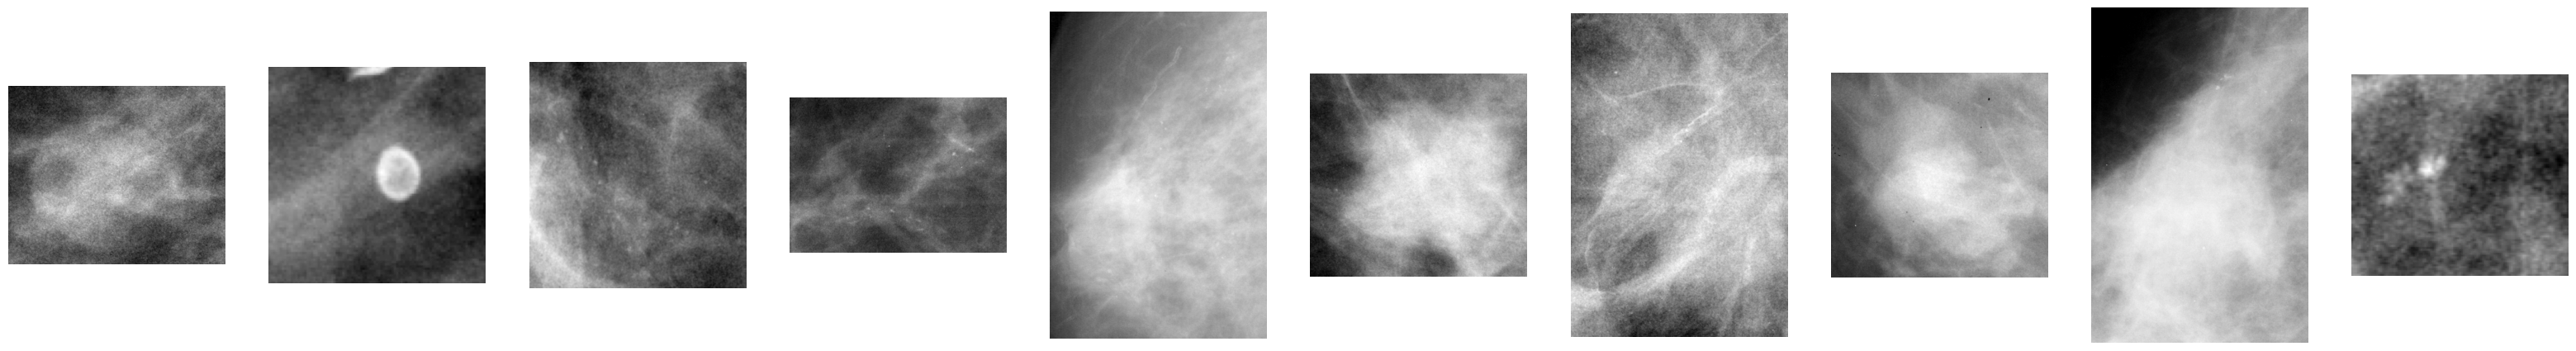

In [16]:
cropped_images = replace_path(cropped_images, "CBIS-DDSM/jpeg", correct_dir)
plot_samples(cropped_images)

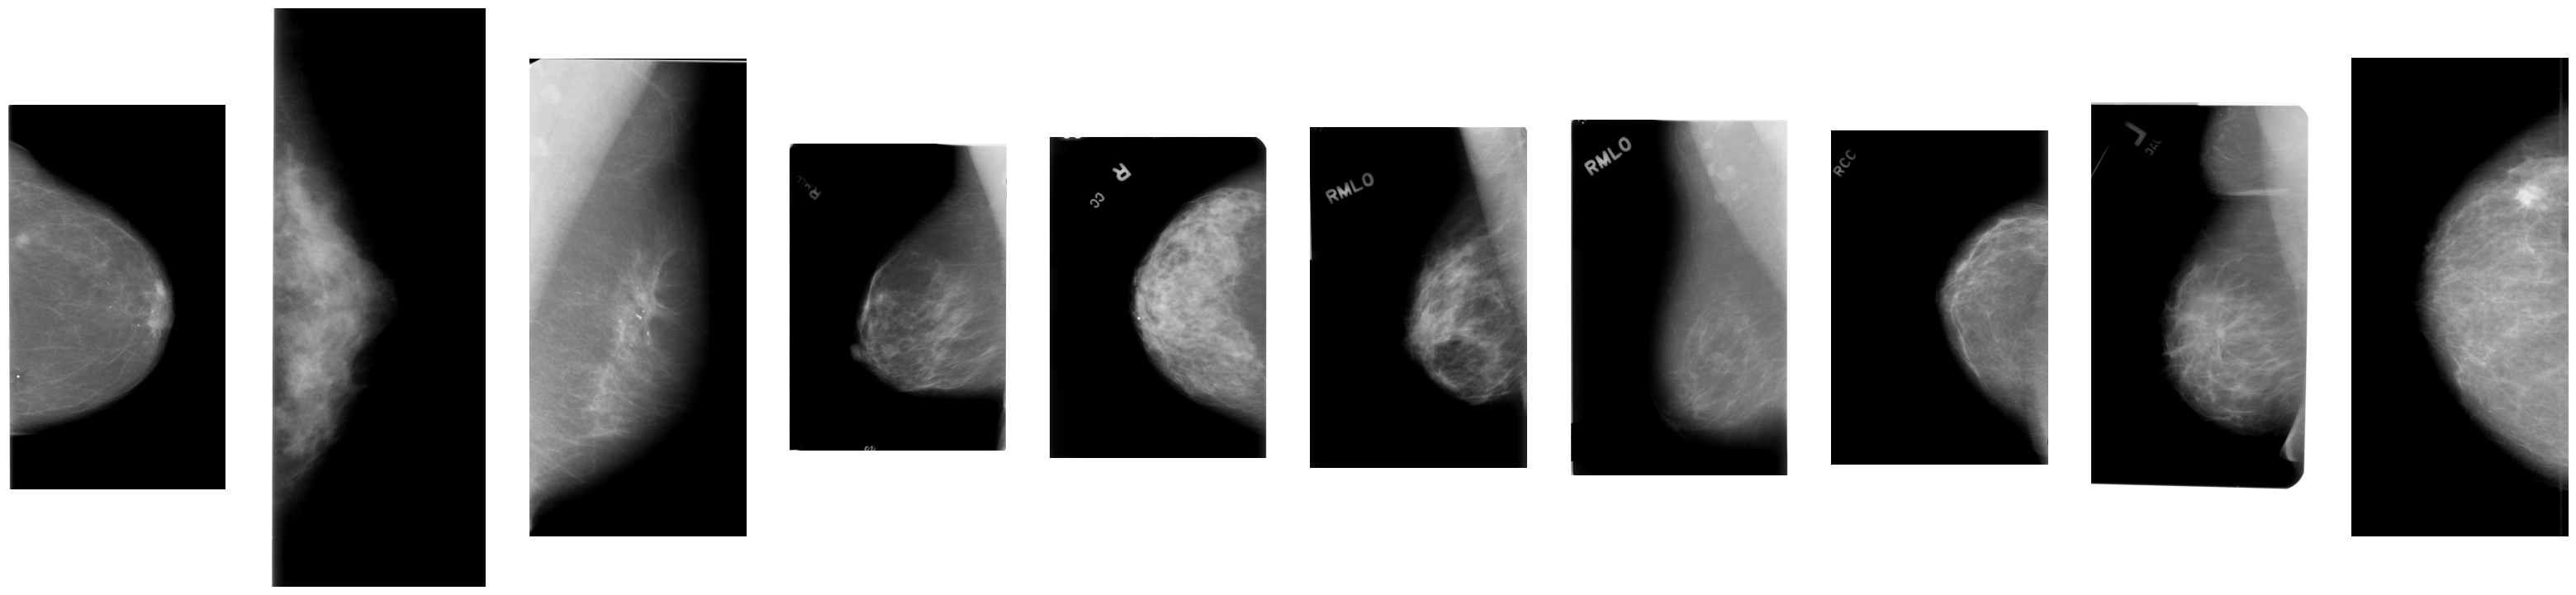

In [17]:
full_mammogram = replace_path(full_mammogram, "CBIS-DDSM/jpeg", correct_dir)
plot_samples(full_mammogram, 40,40)

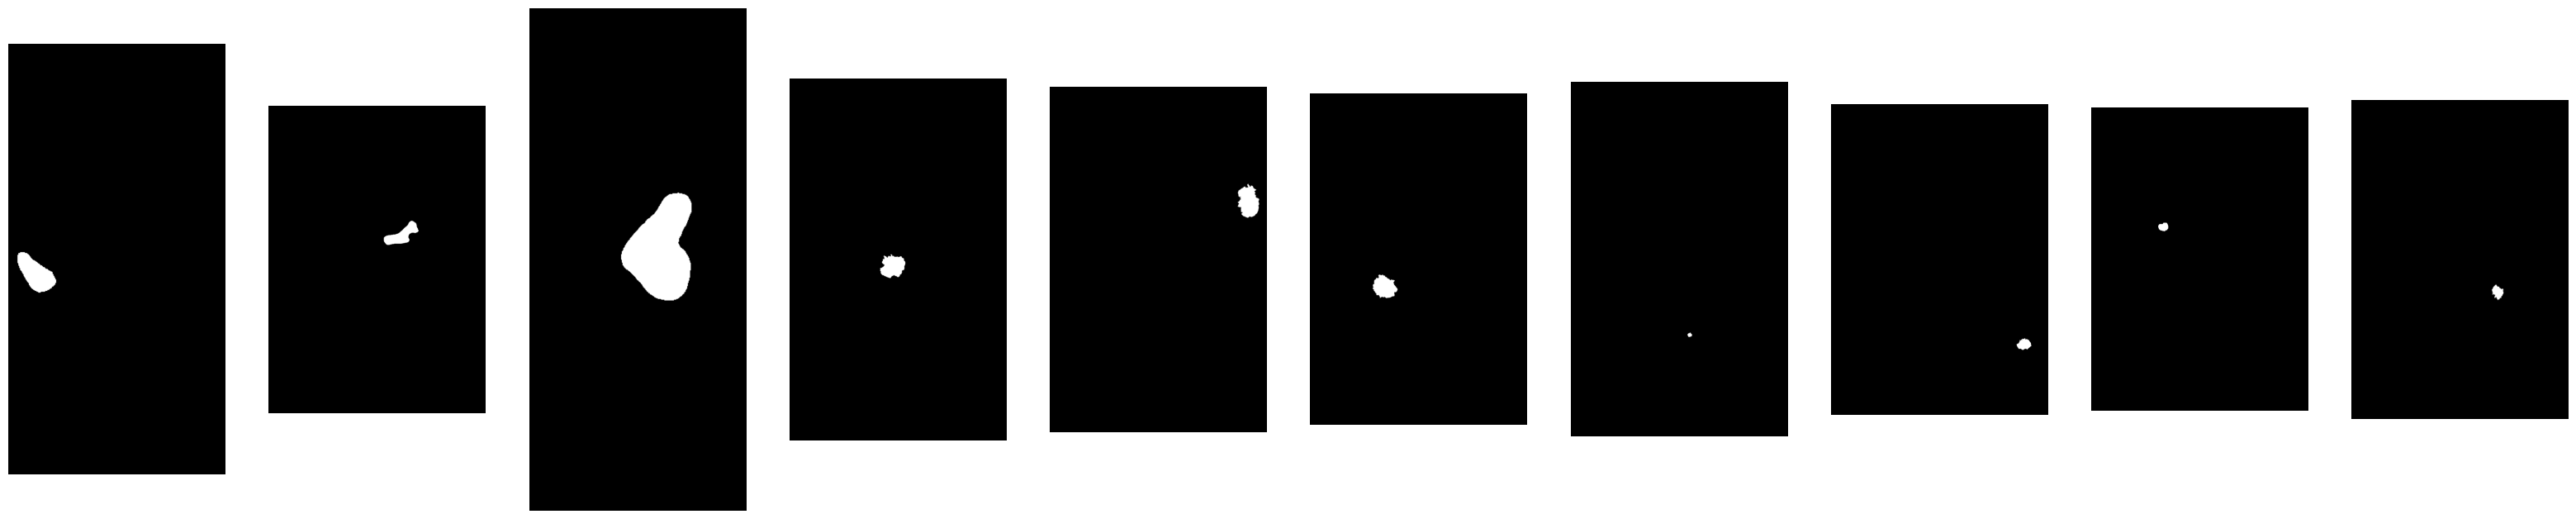

In [18]:
roi_mask = replace_path(roi_mask, "CBIS-DDSM/jpeg", correct_dir)
plot_samples(roi_mask, 40,40)

In [19]:
def get_image_file_name(data, new_dict):
    for dicom in data:
        key = dicom.split('/')[4]
        new_dict[key] = dicom
    print(f"the length of dataset ==> {len(new_dict.keys())}")

In [20]:
cropped_images_dict = dict()
full_mammo_dict = dict()
roi_img_dict = dict()

get_image_file_name(cropped_images, cropped_images_dict)
get_image_file_name(full_mammogram, full_mammo_dict)
get_image_file_name(roi_mask, roi_img_dict)

the length of dataset ==> 3567
the length of dataset ==> 2857
the length of dataset ==> 3247


In [21]:
def fix_image_path(data):
    for indx, image in enumerate(data.values):
        img_name = image[11].split('/')[2]
        if img_name in full_mammo_dict:
            data.iloc[indx, 11] = full_mammo_dict[img_name]
        else:
            data.iloc[indx, 11] = None
        img_name = image[12].split('/')[2]
        if img_name in cropped_images_dict:
            data.iloc[indx, 12] = cropped_images_dict[img_name]
        else:
            data.iloc[indx, 11] = None
        img_name = image[13].split('/')[2]
        if img_name in roi_img_dict:
            data.iloc[indx, 13] = roi_img_dict[img_name]
        else:
            data.iloc[indx, 13] = None

In [22]:
fix_image_path(matr_df)
matr_df = matr_df.rename(columns={'left or right breast': 'left_or_right_breast',
                                        'image view': 'image_view',
                                        'abnormality id': 'abnormality_id',
                                        'abnormality type': 'abnormality_type',
                                        'mass shape': 'mass_shape',
                                        'mass margins': 'mass_margins',
                                        'image file path': 'image_file_path',
                                        'cropped image file path': 'cropped_image_file_path',
                                        'ROI mask file path': 'ROI_mask_file_path'})
matr_df.head(3)

,patient_id,breast_density,left_or_right_breast,image_view,abnormality_id,abnormality_type,mass_shape,mass_margins,assessment,pathology,subtlety,image_file_path,cropped_image_file_path,ROI_mask_file_path
0,P_00001,3,LEFT,CC,1,mass,IRREGULAR-ARCHITECTURAL_DISTORTION,SPICULATED,4,MALIGNANT,4,../input/cbis-ddsm-breast-cancer-image-dataset...,../input/cbis-ddsm-breast-cancer-image-dataset...,../input/cbis-ddsm-breast-cancer-image-dataset...
1,P_00001,3,LEFT,MLO,1,mass,IRREGULAR-ARCHITECTURAL_DISTORTION,SPICULATED,4,MALIGNANT,4,../input/cbis-ddsm-breast-cancer-image-dataset...,../input/cbis-ddsm-breast-cancer-image-dataset...,../input/cbis-ddsm-breast-cancer-image-dataset...
2,P_00004,3,LEFT,CC,1,mass,ARCHITECTURAL_DISTORTION,ILL_DEFINED,4,BENIGN,3,../input/cbis-ddsm-breast-cancer-image-dataset...,../input/cbis-ddsm-breast-cancer-image-dataset...,../input/cbis-ddsm-breast-cancer-image-dataset...


In [23]:
fix_image_path(mate_df)
mate_df= mate_df.rename(columns={'left or right breast': 'left_or_right_breast',
                                      'image view': 'image_view',
                                      'abnormality id': 'abnormality_id',
                                      'abnormality type': 'abnormality_type',
                                      'mass shape': 'mass_shape',
                                      'mass margins': 'mass_margins',
                                      'image file path': 'image_file_path',
                                      'cropped image file path': 'cropped_image_file_path',
                                      'ROI mask file path': 'ROI_mask_file_path'})
mate_df.head(3)

,patient_id,breast_density,left_or_right_breast,image_view,abnormality_id,abnormality_type,mass_shape,mass_margins,assessment,pathology,subtlety,image_file_path,cropped_image_file_path,ROI_mask_file_path
0,P_00016,4,LEFT,CC,1,mass,IRREGULAR,SPICULATED,5,MALIGNANT,5,../input/cbis-ddsm-breast-cancer-image-dataset...,../input/cbis-ddsm-breast-cancer-image-dataset...,../input/cbis-ddsm-breast-cancer-image-dataset...
1,P_00016,4,LEFT,MLO,1,mass,IRREGULAR,SPICULATED,5,MALIGNANT,5,../input/cbis-ddsm-breast-cancer-image-dataset...,../input/cbis-ddsm-breast-cancer-image-dataset...,../input/cbis-ddsm-breast-cancer-image-dataset...
2,P_00017,2,LEFT,CC,1,mass,ROUND,CIRCUMSCRIBED,4,MALIGNANT,4,../input/cbis-ddsm-breast-cancer-image-dataset...,../input/cbis-ddsm-breast-cancer-image-dataset...,../input/cbis-ddsm-breast-cancer-image-dataset...


In [24]:
fix_image_path(catr_df)
catr_df= catr_df.rename(columns={'left or right breast': 'left_or_right_breast',
                                      'image view': 'image_view',
                                      'abnormality id': 'abnormality_id',
                                      'abnormality type': 'abnormality_type',
                                      'mass shape': 'mass_shape',
                                      'mass margins': 'mass_margins',
                                      'image file path': 'image_file_path',
                                      'cropped image file path': 'cropped_image_file_path',
                                      'ROI mask file path': 'ROI_mask_file_path'})
catr_df.head(3)

,patient_id,breast density,left_or_right_breast,image_view,abnormality_id,abnormality_type,calc type,calc distribution,assessment,pathology,subtlety,image_file_path,cropped_image_file_path,ROI_mask_file_path
0,P_00005,3,RIGHT,CC,1,calcification,AMORPHOUS,CLUSTERED,3,MALIGNANT,3,../input/cbis-ddsm-breast-cancer-image-dataset...,../input/cbis-ddsm-breast-cancer-image-dataset...,../input/cbis-ddsm-breast-cancer-image-dataset...
1,P_00005,3,RIGHT,MLO,1,calcification,AMORPHOUS,CLUSTERED,3,MALIGNANT,3,../input/cbis-ddsm-breast-cancer-image-dataset...,../input/cbis-ddsm-breast-cancer-image-dataset...,../input/cbis-ddsm-breast-cancer-image-dataset...
2,P_00007,4,LEFT,CC,1,calcification,PLEOMORPHIC,LINEAR,4,BENIGN,4,../input/cbis-ddsm-breast-cancer-image-dataset...,../input/cbis-ddsm-breast-cancer-image-dataset...,../input/cbis-ddsm-breast-cancer-image-dataset...


In [25]:
fix_image_path(cate_df)
cate_df = cate_df.rename(columns={'left or right breast': 'left_or_right_breast',
                                      'image view': 'image_view',
                                      'abnormality id': 'abnormality_id',
                                      'abnormality type': 'abnormality_type',
                                      'mass shape': 'mass_shape',
                                      'mass margins': 'mass_margins',
                                      'image file path': 'image_file_path',
                                      'cropped image file path': 'cropped_image_file_path',
                                      'ROI mask file path': 'ROI_mask_file_path'})
cate_df.head(3)

,patient_id,breast density,left_or_right_breast,image_view,abnormality_id,abnormality_type,calc type,calc distribution,assessment,pathology,subtlety,image_file_path,cropped_image_file_path,ROI_mask_file_path
0,P_00038,2,LEFT,CC,1,calcification,PUNCTATE-PLEOMORPHIC,CLUSTERED,4,BENIGN,2,None,../input/cbis-ddsm-breast-cancer-image-dataset...,None
1,P_00038,2,LEFT,MLO,1,calcification,PUNCTATE-PLEOMORPHIC,CLUSTERED,4,BENIGN,2,None,../input/cbis-ddsm-breast-cancer-image-dataset...,None
2,P_00038,2,RIGHT,CC,1,calcification,VASCULAR,NaN,2,BENIGN_WITHOUT_CALLBACK,5,None,../input/cbis-ddsm-breast-cancer-image-dataset...,None


In [26]:
def display_images(dataset, column, number):
    fig, axes = plt.subplots(1, number, figsize=(15, 5))
    for index, (i, row) in enumerate(dataset.head(number).iterrows()):
        image_path = row[column]
        if image_path is None or not os.path.exists(image_path):
            continue
        
        image = cv2.imread(image_path)
        
        if image is None:
            continue
        if len(image.shape) == 3 and image.shape[2] == 3:
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        
        ax = axes[index]
        ax.imshow(image, cmap='gray' if len(image.shape) == 2 else None)
        ax.set_title(f"{row['pathology']}")
        ax.axis('off')
        print(np.array(image).shape)
    
    plt.tight_layout()
    plt.show()
    

Full Mammograms:

(4808, 3024, 3)
(4800, 2656, 3)
(5491, 2986, 3)
(5491, 3046, 3)
(5491, 2911, 3)


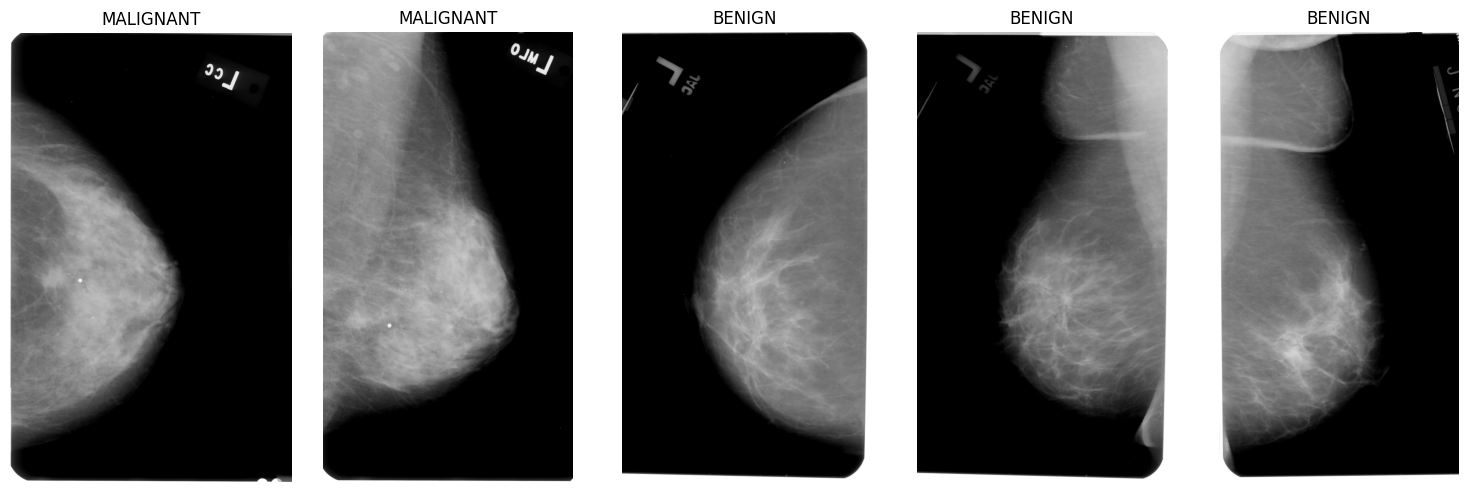

Cropped Mammograms:

(515, 431, 3)
(292, 256, 3)
(466, 423, 3)
(427, 422, 3)
(399, 465, 3)


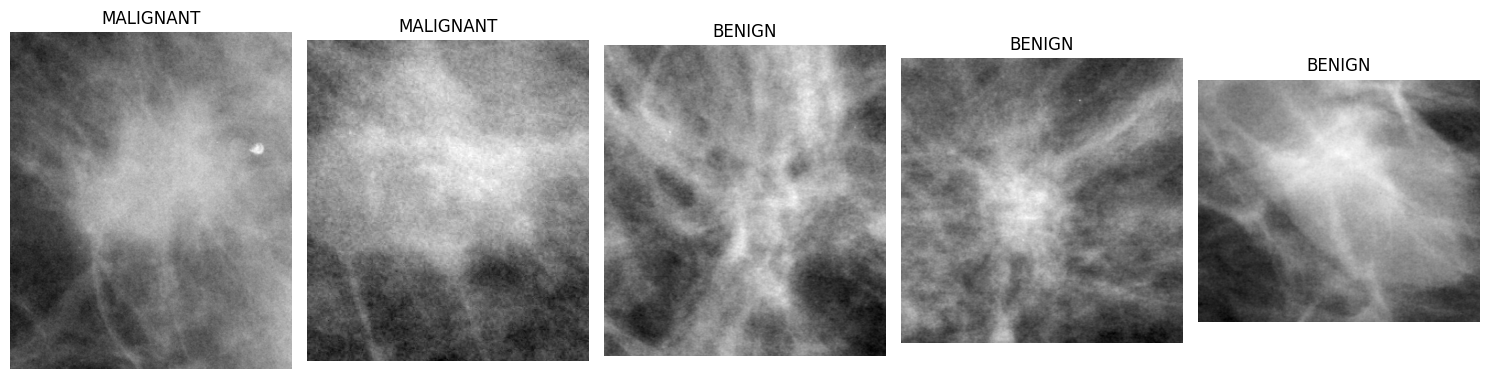

ROI_mask:

(4808, 3024, 3)
(4800, 2656, 3)
(5491, 2986, 3)
(5491, 3046, 3)
(5491, 2911, 3)


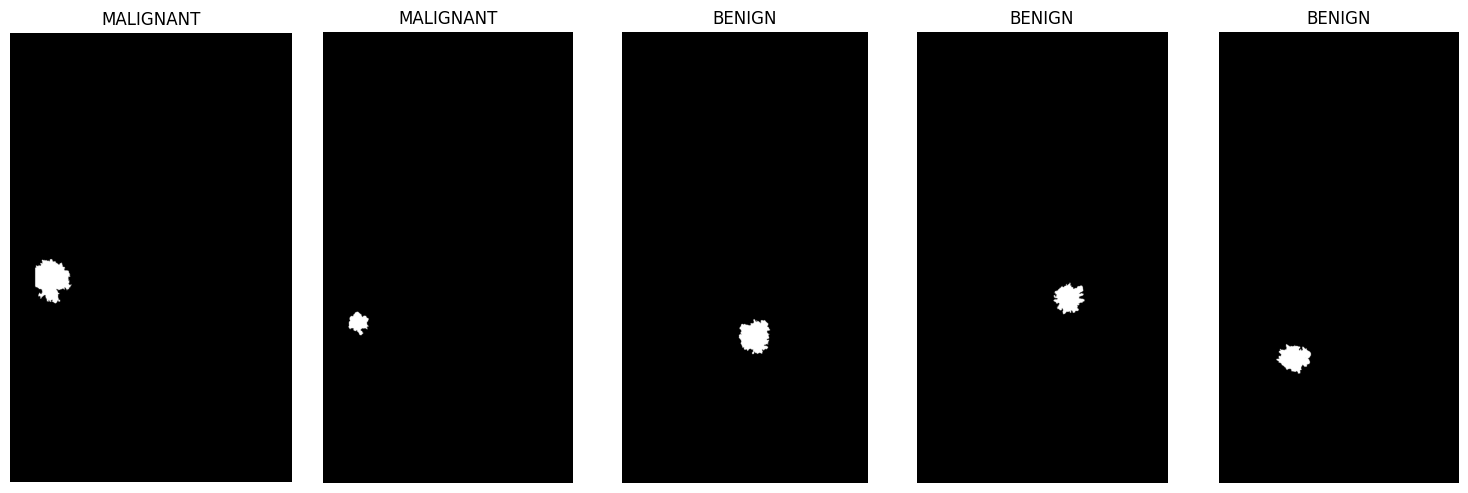

Full Mammograms:

(4006, 1846, 3)
(5491, 2011, 3)
(5904, 3200, 3)
(5952, 3352, 3)
(5116, 2641, 3)


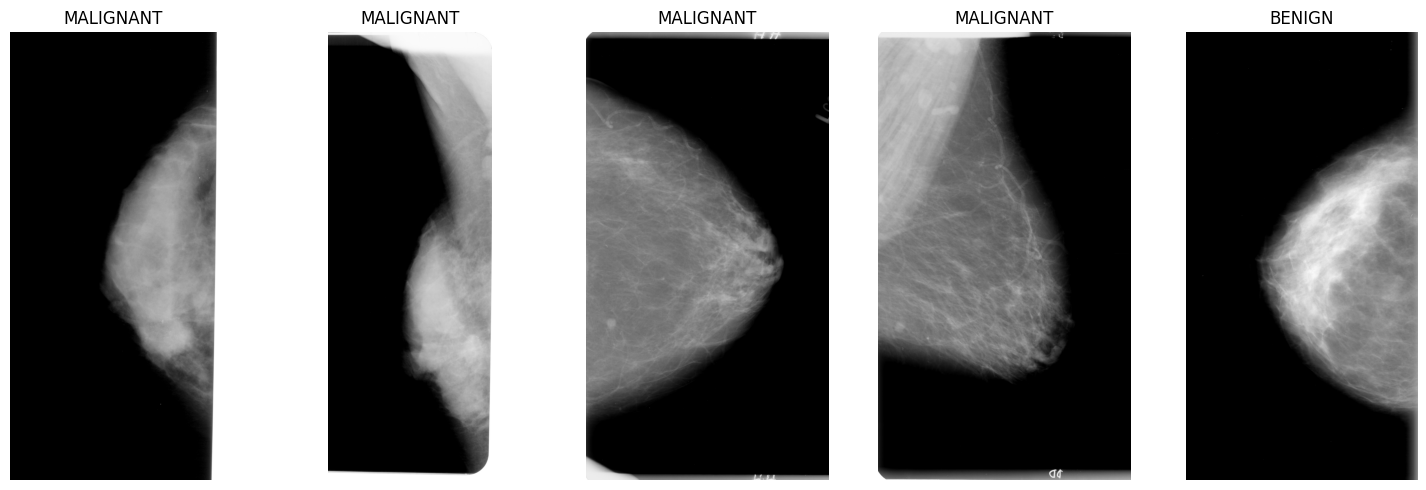

Cropped Mammograms:

(384, 385, 3)
(369, 328, 3)
(214, 195, 3)
(220, 225, 3)
(405, 376, 3)


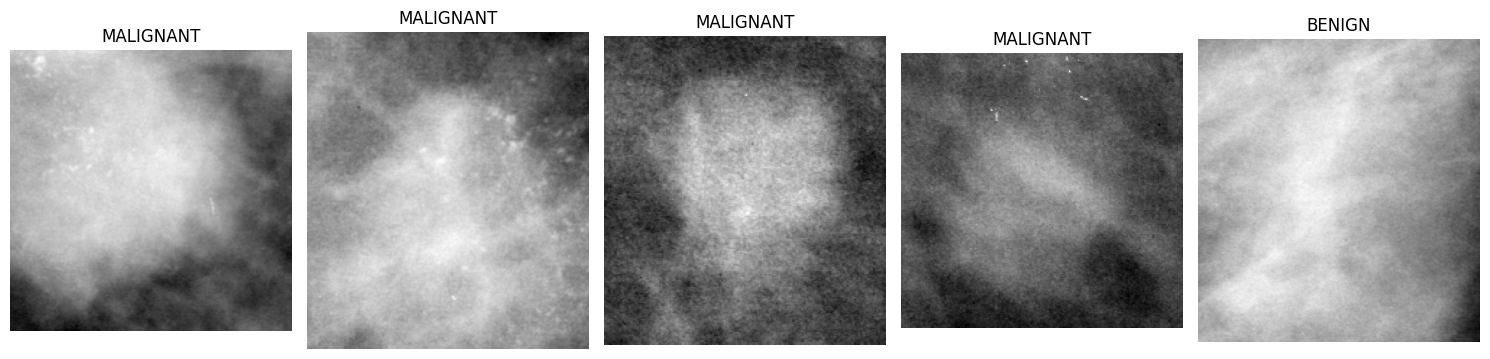

ROI_mask:

(4006, 1846, 3)
(5491, 2011, 3)
(5904, 3200, 3)
(5952, 3352, 3)
(5116, 2641, 3)


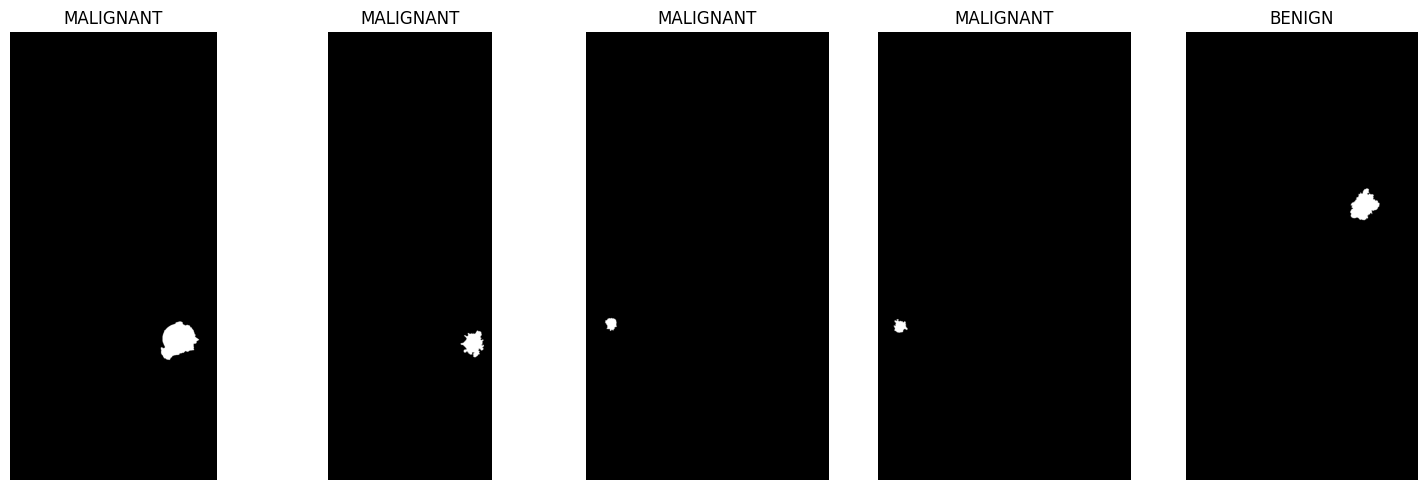

Full Mammograms:

(5056, 2761, 3)
(5386, 2836, 3)
(5356, 2986, 3)
(5491, 3166, 3)
(4568, 3064, 3)


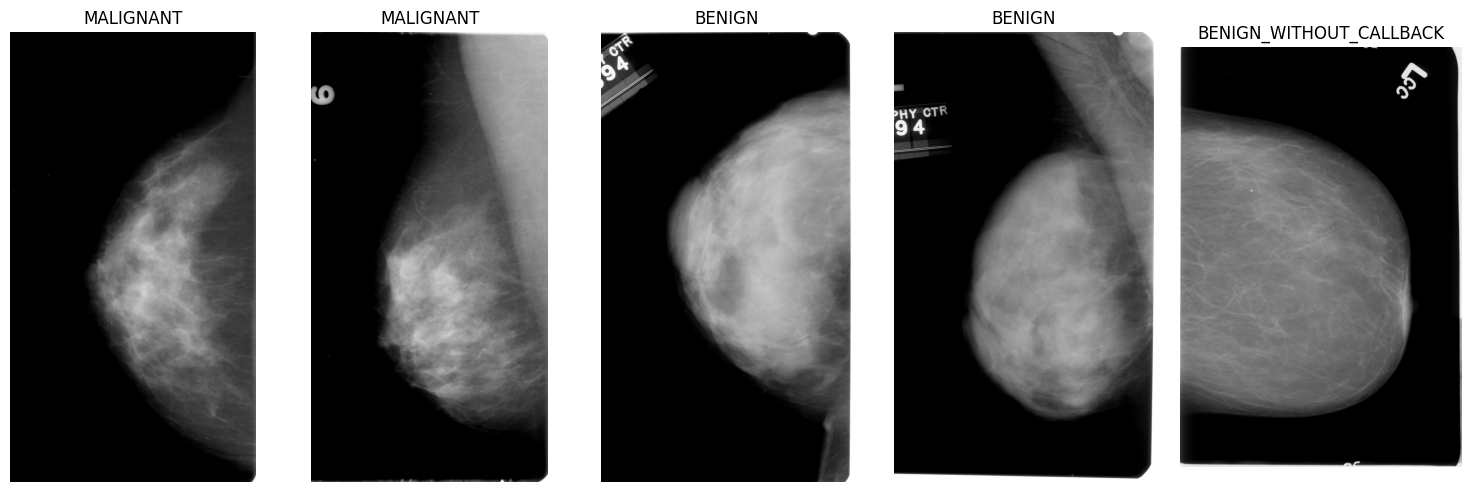

Cropped Mammograms:

(589, 677, 3)
(549, 681, 3)
(681, 577, 3)
(689, 761, 3)
(161, 177, 3)


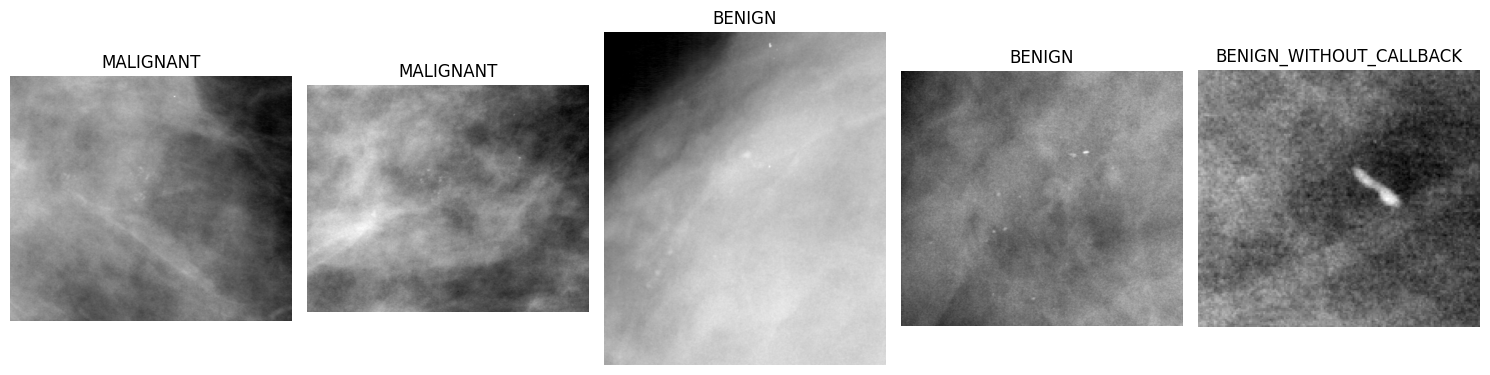

ROI_mask:

(5056, 2761, 3)
(5386, 2836, 3)
(5356, 2986, 3)
(5491, 3166, 3)
(4568, 3064, 3)


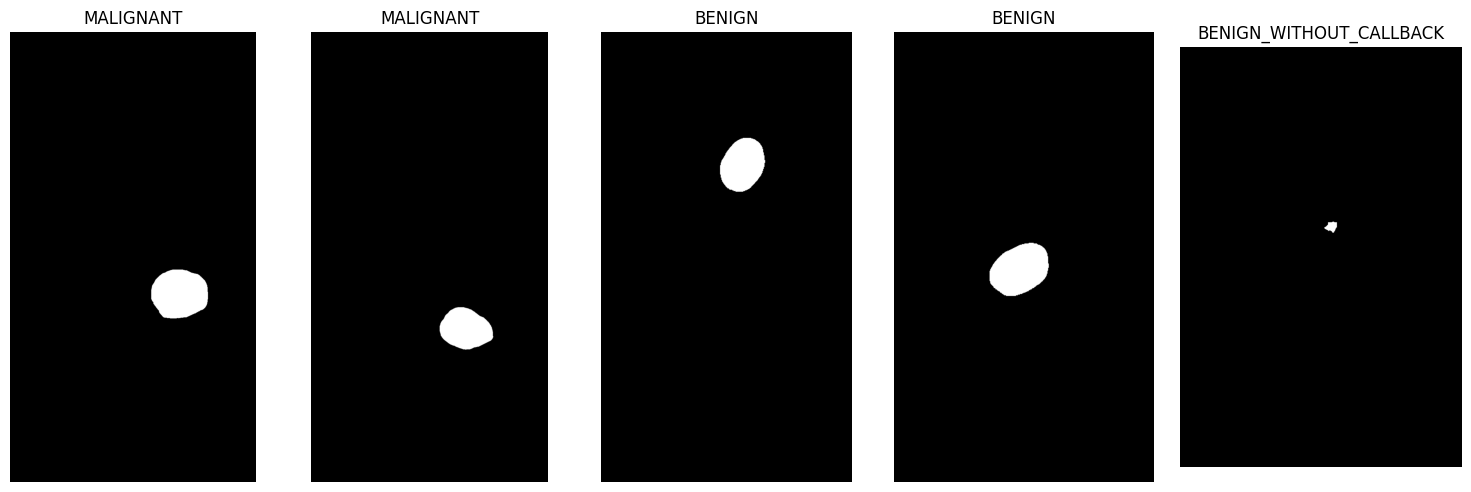

Full Mammograms:



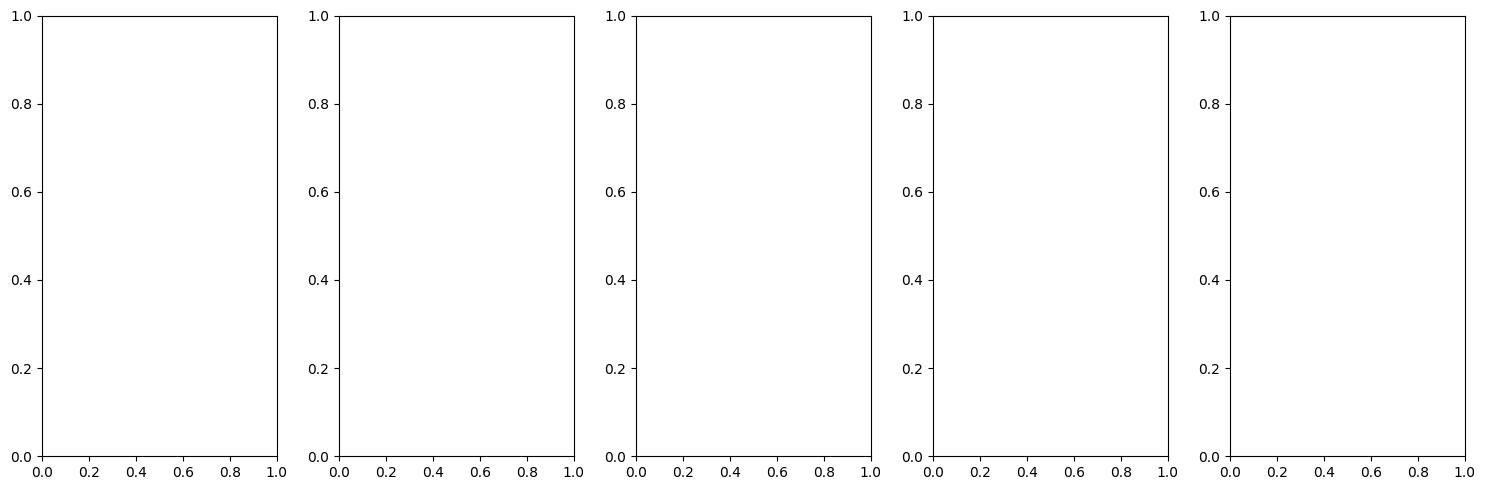

Cropped Mammograms:

(249, 265, 3)
(265, 249, 3)
(409, 660, 3)
(257, 724, 3)
(809, 833, 3)


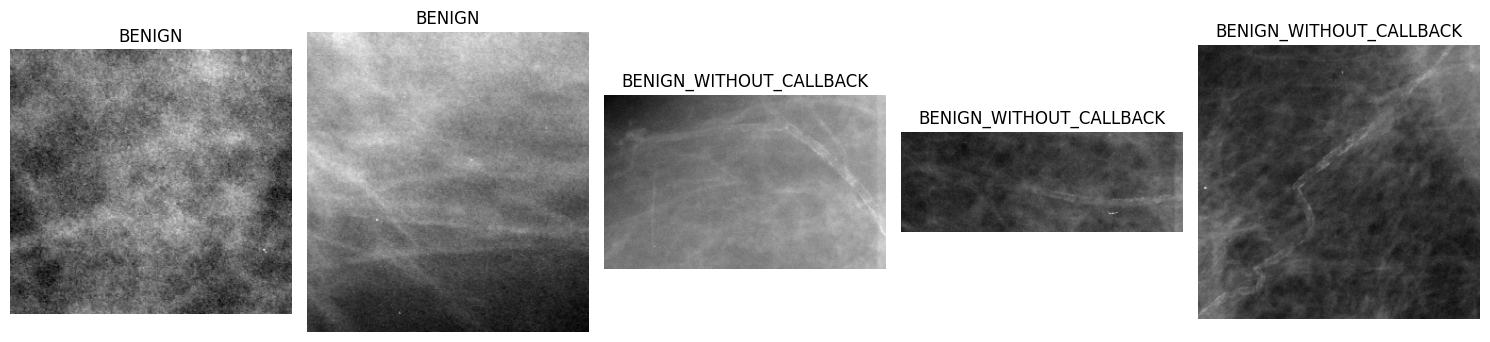

ROI_mask:



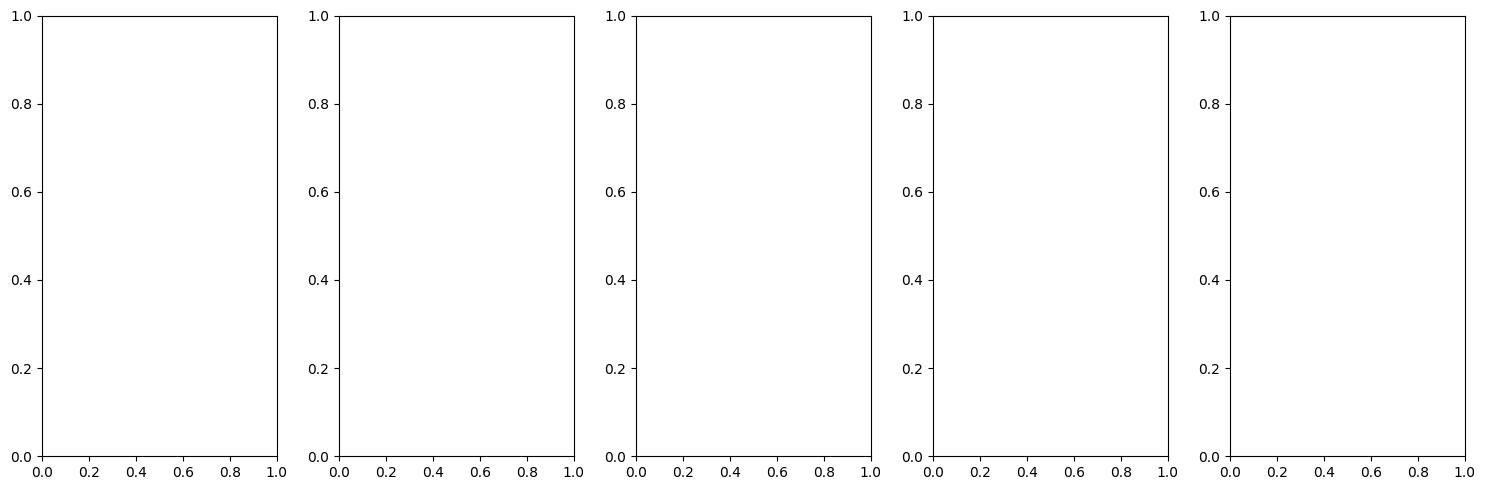

In [27]:
print('Full Mammograms:\n')
display_images(matr_df, 'image_file_path', 5)
print('Cropped Mammograms:\n')
display_images(matr_df, 'cropped_image_file_path', 5)
print('ROI_mask:\n')
display_images(matr_df, 'ROI_mask_file_path', 5)


print('Full Mammograms:\n')
display_images(mate_df, 'image_file_path', 5)
print('Cropped Mammograms:\n')
display_images(mate_df, 'cropped_image_file_path', 5)
print('ROI_mask:\n')
display_images(mate_df, 'ROI_mask_file_path', 5)



print('Full Mammograms:\n')
display_images(catr_df, 'image_file_path', 5)
print('Cropped Mammograms:\n')
display_images(catr_df, 'cropped_image_file_path', 5)
print('ROI_mask:\n')
display_images(catr_df, 'ROI_mask_file_path', 5)


print('Full Mammograms:\n')
display_images(cate_df, 'image_file_path', 5)
print('Cropped Mammograms:\n')
display_images(cate_df, 'cropped_image_file_path', 5)
print('ROI_mask:\n')
display_images(cate_df, 'ROI_mask_file_path', 5)

In [28]:
calc_dataset = pd.concat([catr_df, cate_df], axis=0)

In [29]:
class_mapper = {'MALIGNANT': 1, 'BENIGN': 0, 'BENIGN_WITHOUT_CALLBACK': 0} 

In [30]:
target_size = (224, 224, 3) #The height and width of the image (in pixels).The number of color channels (RGB → Red, Green, Blue).

In [31]:
# maps pathology labels to numerical values, and extracts valid image paths and their corresponding labels.
calc_dataset['labels'] = calc_dataset['pathology'].replace(class_mapper).infer_objects(copy=False)

calc_images = np.array(calc_dataset[calc_dataset["image_file_path"].notna()]["image_file_path"].tolist())
calc_labels = np.array(calc_dataset[calc_dataset["image_file_path"].notna()]["labels"].tolist())

/tmp/ipykernel_19/898833361.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  calc_dataset['labels'] = calc_dataset['pathology'].replace(class_mapper).infer_objects(copy=False)


In [32]:
full_labels_series = pd.Series(calc_labels)

# Count the occurrences of each class
label_counts = full_labels_series.value_counts()

# Assuming 0 = benign and 1 = malignant
benign_count = label_counts.get(0, 0)
malignant_count = label_counts.get(1, 0)

print(f"Benign images: {benign_count}")
print(f"Malignant images: {malignant_count}")

Benign images: 1018
Malignant images: 570


In [33]:
def images_count():
    zero_class_count = len(os.listdir("/kaggle/working/merged_images/0"))
    one_class_count  = len(os.listdir("/kaggle/working/merged_images/1"))

    print(f"Number of images in class 0: {zero_class_count}")
    print(f"Number of images in class 1: {one_class_count}")

In [34]:
#data augmentation techniques to an image using TensorFlow's tf.image module. Data augmentation artificially increases dataset diversity by applying random transformations, making the model more robust and generalized.
def augment_image(image):
    # Apply data augmentation using tf.image functions
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_brightness(image, max_delta=0.3)
    image = tf.image.random_contrast(image, lower=0.8, upper=1.2)
    image = tf.image.random_saturation(image, lower=0.8, upper=1.2)
    return image

# Function to resize image to (224, 224, 3)
def resize_image(image_tensor):
    return tf.image.resize(image_tensor, [224, 224])

# Function to balance classes by augmenting images
def copy_images_with_unique_filenames(images, labels, source, destination, target_count=None):
    
    benign_images = 0
    malignant_images = 0
    skipped_images = []

    # Create the destination subfolders '0' and '1'
    category_dest_dir_zero = os.path.join(destination, '0')
    os.makedirs(category_dest_dir_zero, exist_ok=True)

    category_dest_dir_one = os.path.join(destination, '1')
    os.makedirs(category_dest_dir_one, exist_ok=True)

    benign_images_list = []
    malignant_images_list = []

    for i, (image, label) in enumerate(zip(images, labels)):
        if os.path.exists(image):
            try:
                # Generate a unique filename
                filename = os.path.basename(image)
                unique_filename = f"{uuid.uuid4().hex}_{filename}"
        
                # Open the image using PIL
                with Image.open(image) as img:
                    # Convert the image to RGB mode (for saving as JPEG)
                    img = img.convert('RGB')
                    # Augment the image (convert it to a Tensor first)
                    img_tensor = tf.convert_to_tensor(img)
                    # Resize the image to (224, 224, 3)
                    resized_img_tensor = resize_image(img_tensor)
                    augmented_image_tensor = augment_image(resized_img_tensor)
                    # Convert Tensor back to PIL image for saving
                    augmented_image = tf.keras.preprocessing.image.array_to_img(augmented_image_tensor)

                    if label == 0:
                        benign_images_list.append(unique_filename)
                        dest_path = os.path.join(category_dest_dir_zero, unique_filename)
                        augmented_image.save(dest_path, 'JPEG')
                        benign_images += 1

                    elif label == 1:
                        malignant_images_list.append(unique_filename)
                        dest_path = os.path.join(category_dest_dir_one, unique_filename)
                        augmented_image.save(dest_path, 'JPEG')
                        malignant_images += 1

            except Exception as e:
                print(f"Error copying image {image}: {e}")
                skipped_images.append(image)
        else:
            print(f"Image not found: {image}")
            skipped_images.append(image)

    # If balancing is needed, duplicate/augment images from the smaller class
    benign_count = len(benign_images_list)
    malignant_count = len(malignant_images_list)

    if benign_count < malignant_count:
        augment_and_save_images(benign_images_list, category_dest_dir_zero, malignant_count - benign_count)

    elif malignant_count < benign_count:
        augment_and_save_images(malignant_images_list, category_dest_dir_one, benign_count - malignant_count)
    print("data balancing")
    images_count()
    augment_and_save_images(benign_images_list, category_dest_dir_zero, target_count)
    augment_and_save_images(malignant_images_list, category_dest_dir_one, target_count)
    print("data augmentation")
    images_count()
    
    print(f"\nCopying complete.")
    print(f"Benign images copied (label 0): {benign_images}")
    print(f"Benign count (label 0): {benign_count}")
    print(f"Malignant images copied (label 1): {malignant_images}")
    print(f"Malignant count (label 1): {malignant_count}")
    print(f"Total skipped images: {len(skipped_images)}")
    if skipped_images:
        print("Skipped images:")
        for img in skipped_images:
            print(img)
            
    del skipped_images, benign_images_list, malignant_images_list
    gc.collect()

# Function to augment and save images to balance the dataset
def augment_and_save_images(images_list, destination_dir, num_augments):
    for i in range(num_augments):
        img_name = random.choice(images_list)
        abs_path = os.path.join(destination_dir, img_name)

        try:
            with Image.open(abs_path) as img:
                img = img.convert('RGB')
                # Augment the image
                img_tensor = tf.convert_to_tensor(img)
                # Resize the image
                augmented_image_tensor = augment_image(img_tensor)
                # Convert Tensor back to PIL image for saving
                augmented_image = tf.keras.preprocessing.image.array_to_img(augmented_image_tensor)
                # Remove the original extension from img_name 1-285.jpg --> 1-285
                img_name_without_ext = os.path.splitext(img_name)[0]
                # Save augmented image with a unique name
                augmented_image.save(os.path.join(destination_dir, img_name_without_ext + f'_aug{i}.jpg'), 'JPEG')
        except Exception as e:
            print(f"Error augmenting image {abs_path}: {e}")

# Example usage
source_dir = "/kaggle/input/mias-mammography/all-mias"
destination_dir = "/kaggle/working/merged_images"

# target_count=0 meaning no Augmentation, There's just Data-Balance
target_count = int((len(calc_labels) * 5) // 2)
copy_images_with_unique_filenames(calc_images, calc_labels, source_dir, destination_dir, target_count)

I0000 00:00:1754175123.902042      19 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1754175123.902736      19 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


data balancing
Number of images in class 0: 1018
Number of images in class 1: 1018
data augmentation
Number of images in class 0: 4988
Number of images in class 1: 4988

Copying complete.
Benign images copied (label 0): 1018
Benign count (label 0): 1018
Malignant images copied (label 1): 570
Malignant count (label 1): 570
Total skipped images: 0


In [35]:
data_dir = '/kaggle/working/merged_images'  # Update with your dataset path

# Create a dataset for the entire data to use for split
full_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir,
    labels='inferred',
    label_mode='categorical',
    # image_size=(224, 224),
    image_size=(224, 224),
    seed=30,
    shuffle=True,
    batch_size=32  # Set your desired batch size -- switch to 32
)

Found 9976 files belonging to 2 classes.


Shape of Images: (32, 224, 224, 3)
Shape of Labels: (32, 2)

First 10 Labels (One-Hot Encoded):
 [[0. 1.]
 [0. 1.]
 [1. 0.]
 [1. 0.]
 [0. 1.]
 [1. 0.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [1. 0.]]


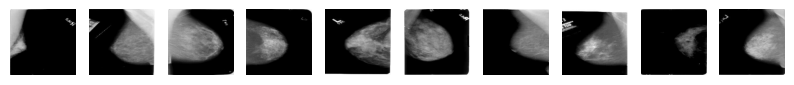

In [36]:
for images, labels in full_dataset.take(1):  # Take the first batch
    print("Shape of Images:", images.shape)  # Should be (batch_size, 224, 224, 3)
    print("Shape of Labels:", labels.shape)  # Should be (batch_size, number_of_classes)
    
    # Print first 5 label values
    print("\nFirst 10 Labels (One-Hot Encoded):\n", labels.numpy()[:10])
    
    # Display some images with their labels
    plt.figure(figsize=(10, 5))
    for i in range(min(10, len(images))): 
        plt.subplot(1, 10, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))  # Convert tensor to image format
        plt.axis("off")
    plt.show()

In [37]:
total_samples = tf.data.experimental.cardinality(full_dataset).numpy()

# Step 3: Split the dataset into train, validation, and test sets
train_size = int(0.8* total_samples)                 # 80% for training
test_size = total_samples - train_size                # 20% for testing

# Create train, validation, and test datasets
train_dataset       = full_dataset.take(train_size)
test_dataset        = full_dataset.skip(train_size)

# Prefetch to Improve Performance
train_dataset      = train_dataset.prefetch(buffer_size=tf.data.experimental.AUTOTUNE)
test_dataset       = test_dataset.prefetch(buffer_size=tf.data.experimental.AUTOTUNE)

# Print the number of samples in each dataset
print(f"Train samples:      {train_size}     batches(8) ==> {train_size*32}")
print(f"Test samples:       {test_size}      batches(8) ==> {test_size*32}")

Train samples:      249     batches(8) ==> 7968
Test samples:       63      batches(8) ==> 2016


In [38]:
def check_missing_samples(dataset, dataset_name):
    missing_count = 0
    for batch, labels in dataset:
        batch_nan = np.any(np.isnan(batch.numpy()))  # Check if any image has NaN values
        label_nan = np.any(np.isnan(labels.numpy()))  # Check if any label is NaN
        
        if batch_nan or label_nan:
            missing_count += 1
    
    print(f"{dataset_name}: Found {missing_count} batches with missing values")

# Check both training and test datasets
check_missing_samples(train_dataset, "Train Dataset")
check_missing_samples(test_dataset, "Test Dataset")

Train Dataset: Found 0 batches with missing values
Test Dataset: Found 0 batches with missing values


In [39]:
#applies a negative transformation to medical images (benign & malignant cases) and saves them in a new directory.
#The negative transformation helps enhance contrast and highlight subtle patterns,


# Define the data directory and the output directory
data_dir = '/kaggle/working/merged_images'
Neg_dir = '/kaggle/working/Negative_Images'

# Create the output directory if it doesn't exist
os.makedirs(Neg_dir, exist_ok=True)

# Define the subdirectories for benign and malignant images
subdirs = ['0', '1']  # 0 for Benign, 1 for Malignant

for subdir in subdirs:
    # Create a corresponding subdirectory in the output directory
    os.makedirs(os.path.join(Neg_dir, subdir), exist_ok=True)
    
    # Define the path to the current subdirectory
    current_dir = os.path.join(data_dir, subdir)
    
    # Loop through all images in the current subdirectory
    for filename in os.listdir(current_dir):
        # Construct the full file path
        file_path = os.path.join(current_dir, filename)
        
        # Read the image
        image = cv2.imread(file_path)
        
        # Check if the image was loaded successfully
        if image is not None:
            # Convert to grayscale (if necessary)
            gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
            
            # Apply negative transformation
            negative_image = 255 - gray_image
            
            # Save the negative image in the corresponding output directory
            output_file_path = os.path.join(Neg_dir, subdir, filename)
            cv2.imwrite(output_file_path, negative_image)
        else:
            print(f"Warning: Could not read image {file_path}")

print("Negative transformation applied and images saved successfully.")

Negative transformation applied and images saved successfully.


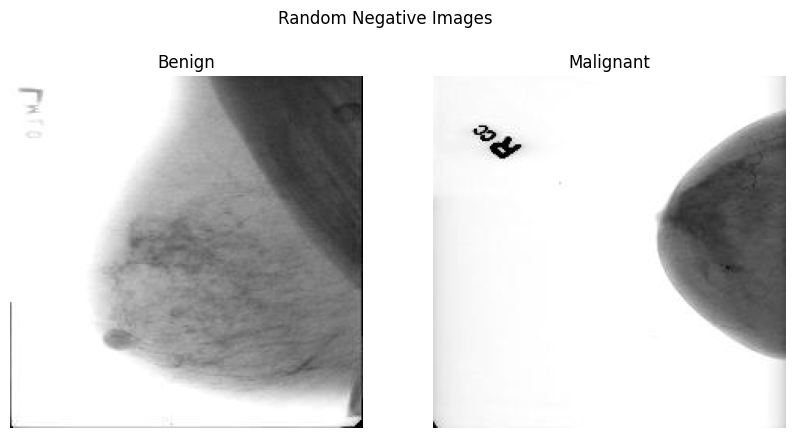

In [40]:
#Verifies that negative images were correctly processed
#Ensures the images are properly stored in their respective directories (0 = Benign, 1 = Malignant)
#Helps identify errors or incorrect image transformations
#Useful for sanity checks before training ResNet50 on negative images

import random


# Function to display one random sample image from each category
def display_random_samples(output_dir, subdirs):
    plt.figure(figsize=(10, 5))
    
    for subdir in subdirs:
        current_dir = os.path.join(output_dir, subdir)
        sample_files = os.listdir(current_dir)
        
        # Select a random file from the list
        if sample_files:  # Check if there are any files
            random_file = random.choice(sample_files)
            file_path = os.path.join(current_dir, random_file)
            image = cv2.imread(file_path, cv2.IMREAD_GRAYSCALE)  # Read in grayscale for display
            
            plt.subplot(1, 2, int(subdir) + 1)
            plt.imshow(image, cmap='gray')
            plt.title('Benign' if subdir == '0' else 'Malignant')
            plt.axis('off')
    
    plt.suptitle('Random Negative Images')
    plt.show()

# Display one random sample from the output directory
display_random_samples(Neg_dir, subdirs)

In [41]:
pip install -q scikit-image

Note: you may need to restart the kernel to use updated packages.


In [42]:
#Enhances contrast in medical images (especially mammograms).
#Makes tumors, tissues, and patterns more visible.
#Prepares preprocessed images for ResNet50 training.
#Ensures equal brightness across different regions (compared to standard histogram equalization).

from skimage import exposure

# Define the data directory and the output directory
data_dir = '/kaggle/working/merged_images'
AHE_dir = '/kaggle/working/AHistogram_Images'

# Create the output directory if it doesn't exist
os.makedirs(AHE_dir, exist_ok=True)

# Define the subdirectories for benign and malignant images
subdirs = ['0', '1']  # 0 for Benign, 1 for Malignant

# Function to apply Adaptive Histogram Equalization and save images
def apply_adaptive_histogram_equalization(data_dir, output_dir):
    for subdir in subdirs:
        # Create a corresponding subdirectory in the output directory
        os.makedirs(os.path.join(output_dir, subdir), exist_ok=True)
        
        # Define the path to the current subdirectory
        current_dir = os.path.join(data_dir, subdir)
        
        # Loop through all images in the current subdirectory
        for filename in os.listdir(current_dir):
            # Construct the full file path
            file_path = os.path.join(current_dir, filename)
            
            # Read the image
            image = cv2.imread(file_path)
            
            # Check if the image was loaded successfully
            if image is not None:
                # Convert to grayscale
                gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
                
                # Apply Adaptive Histogram Equalization
                image_adapteq = exposure.equalize_adapthist(gray_image, clip_limit=0.03)
                
                # Convert the image back to uint8 format (0-255)
                image_adapteq = (image_adapteq * 255).astype(np.uint8)
                
                # Save the equalized image in the corresponding output directory
                output_file_path = os.path.join(output_dir, subdir, filename)
                cv2.imwrite(output_file_path, image_adapteq)
            else:
                print(f"Warning: Could not read image {file_path}")

# Call the function to apply the transformation
apply_adaptive_histogram_equalization(data_dir, AHE_dir)

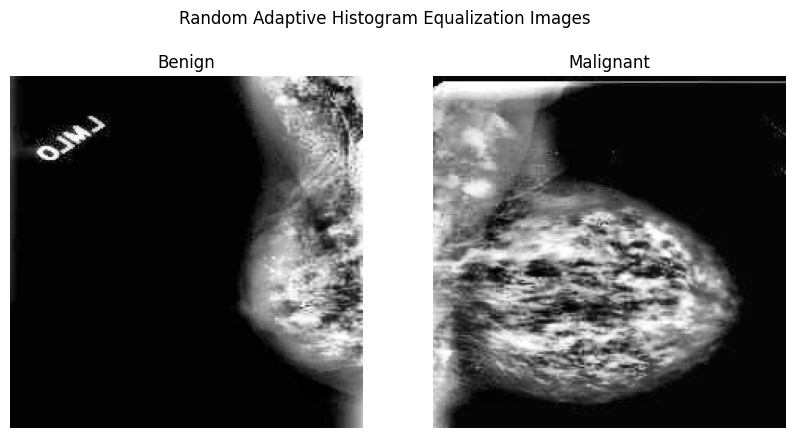

In [43]:
# Function to display one random sample image from each category
def display_random_samples(output_dir, subdirs):
    plt.figure(figsize=(10, 5))
    
    for subdir in subdirs:
        current_dir = os.path.join(output_dir, subdir)
        sample_files = os.listdir(current_dir)
        
        # Select a random file from the list
        if sample_files:  # Check if there are any files
            random_file = random.choice(sample_files)
            file_path = os.path.join(current_dir, random_file)
            image = cv2.imread(file_path, cv2.IMREAD_GRAYSCALE)  # Read in grayscale for display
            
            plt.subplot(1, 2, int(subdir) + 1)
            plt.imshow(image, cmap='gray')
            plt.title('Benign' if subdir == '0' else 'Malignant')
            plt.axis('off')
    
    plt.suptitle('Random Adaptive Histogram Equalization Images')
    plt.show()


# Display one random sample from the output directory
display_random_samples('/kaggle/working/AHistogram_Images', subdirs)

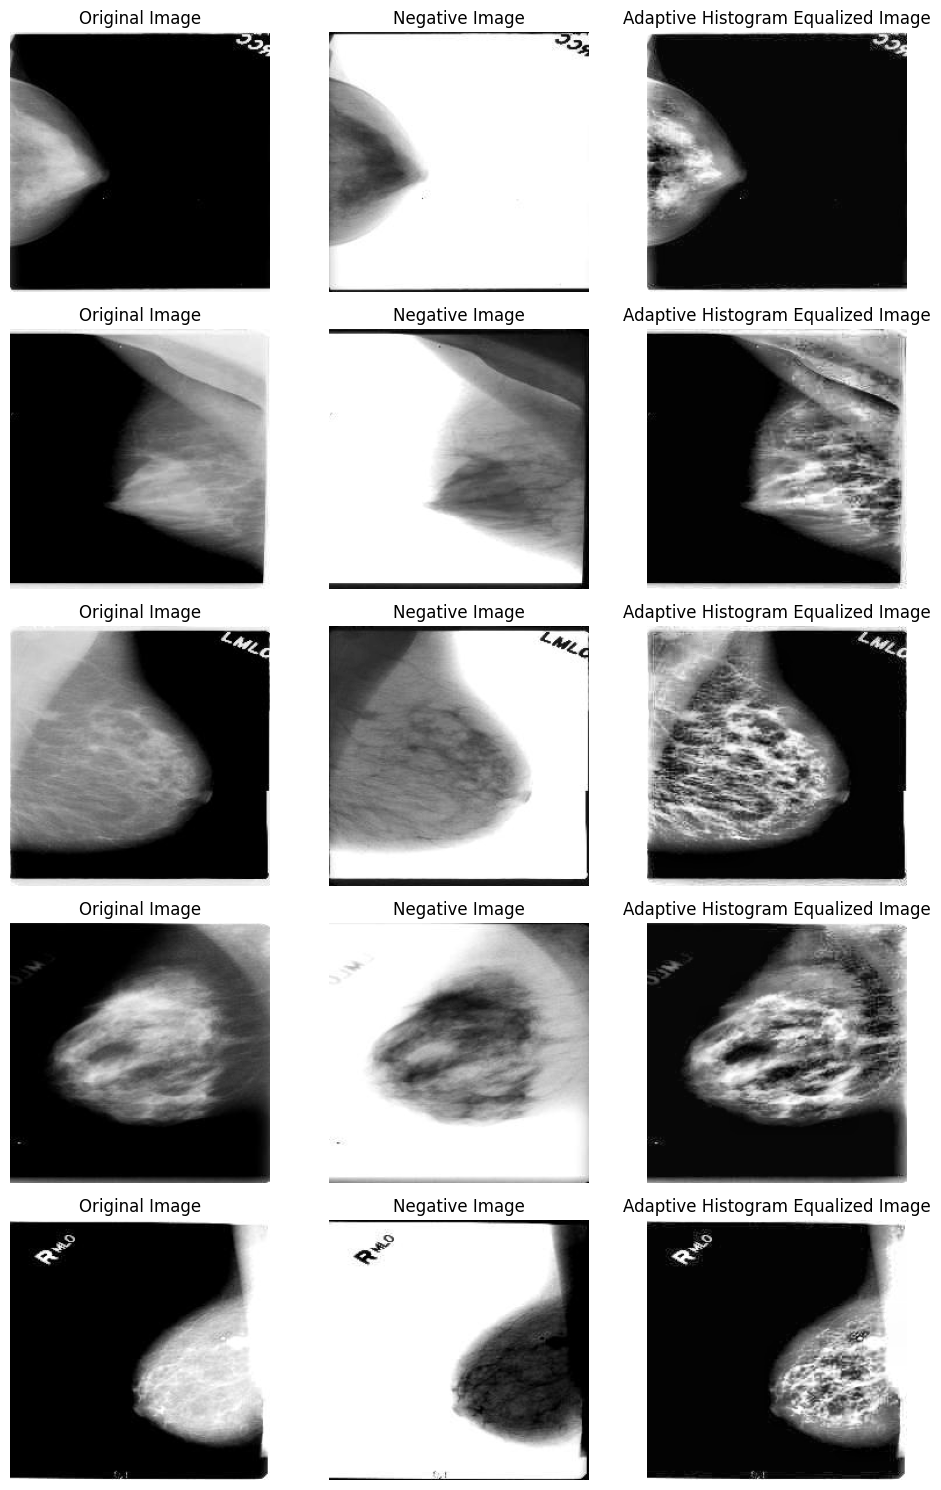

In [44]:
def display_images():
    # Get the image names from the merged images directory
    image_names = [f for f in os.listdir('/kaggle/working/merged_images/1') if f.endswith(('.jpg', '.png'))][:5]

    # Create subplots for 5 images and 3 columns (original, Negative , Adaptive histogram equalized)
    fig, axs = plt.subplots(5, 3, figsize=(10, 15))

    for i, image_name in enumerate(image_names):
        # Get the full paths to the images
        image_path1 = os.path.join('/kaggle/working/merged_images/1', image_name)  # Original Image
        image_path2 = os.path.join('/kaggle/working/Negative_Images/1', image_name)  # Negative Image
        image_path3 = os.path.join('/kaggle/working/AHistogram_Images/1', image_name)  # Adaptive Histogram Equalized Image

        # Open the images
        image1 = Image.open(image_path1).convert('L')  # Convert to grayscale for original
        image2 = Image.open(image_path2)
        image3 = Image.open(image_path3)

        # Display the images in the subplots
        axs[i, 0].imshow(image1, cmap='gray')
        axs[i, 0].axis('off')
        axs[i, 0].set_title('Original Image')

        axs[i, 1].imshow(image2, cmap='gray')
        axs[i, 1].axis('off')
        axs[i, 1].set_title('Negative Image')

        axs[i, 2].imshow(image3, cmap='gray')
        axs[i, 2].axis('off')
        axs[i, 2].set_title('Adaptive Histogram Equalized Image')

    plt.tight_layout()
    plt.show()

display_images()

In [45]:
from skimage import feature

# Define the data directory and the output directory
data_dir = '/kaggle/working/merged_images'
output_dir = '/kaggle/working/Hog_Images'

# Create the output directory if it doesn't exist
os.makedirs(output_dir, exist_ok=True)

# Define the subdirectories for benign and malignant images
subdirs = ['0', '1']  # 0 for Benign, 1 for Malignant

def apply_hog_and_save(data_dir, output_dir):
    # Iterate through each subdirectory
    for subdir in subdirs:
        # Create a corresponding subdirectory in the output directory
        os.makedirs(os.path.join(output_dir, subdir), exist_ok=True)
        
        # Define the path to the current subdirectory
        current_dir = os.path.join(data_dir, subdir)
        
        # Get the list of image files in the current subdirectory
        image_files = os.listdir(current_dir)
        
        # Process each image file
        for filename in image_files:
            # Prepare the full path for the image
            file_path = os.path.join(current_dir, filename)
            output_path = os.path.join(output_dir, subdir, filename)
            
            # Read the image
            image = cv2.imread(file_path)
        
            # Check if the image was loaded successfully
            if image is not None:
                # Convert to grayscale
                gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
                
                # Compute HOG features
                hog_features, hog_image = feature.hog(
                    gray_image,
                    orientations=9,
                    pixels_per_cell=(8, 8),
                    cells_per_block=(2, 2),
                    visualize=True
                )
                
                # Scale the HOG image for better visualization
                hog_image = (hog_image * 255).astype(np.uint8)
                
                # Save the HOG image
                cv2.imwrite(output_path, hog_image)
            else:
                print(f"Warning: Could not read image {file_path}")

# Call the function to apply HOG and save images
apply_hog_and_save(data_dir, output_dir)

print("HOG features extracted and images saved successfully.")

HOG features extracted and images saved successfully.


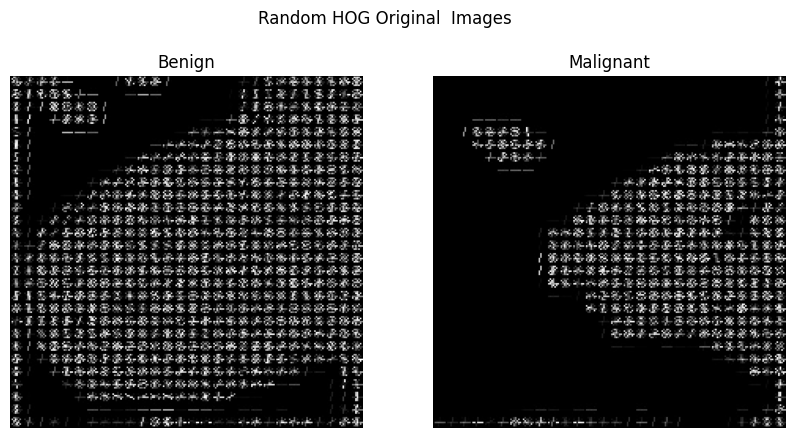

In [46]:
# Function to display one random sample image from each category
def display_random_samplesHog(output_dir, subdirs):
    plt.figure(figsize=(10, 5))
    
    for subdir in subdirs:
        current_dir = os.path.join(output_dir, subdir)
        sample_files = os.listdir(current_dir)
        
        # Select a random file from the list
        if sample_files:  # Check if there are any files
            random_file = random.choice(sample_files)
            file_path = os.path.join(current_dir, random_file)
            image = cv2.imread(file_path, cv2.IMREAD_GRAYSCALE)  # Read in grayscale for display
            
            plt.subplot(1, 2, int(subdir) + 1)
            plt.imshow(image, cmap='gray')
            plt.title('Benign' if subdir == '0' else 'Malignant')
            plt.axis('off')
    
    plt.suptitle('Random HOG Original  Images')
    plt.show()

subdirs = ['0', '1']

# Display one random sample from the output directory
display_random_samplesHog('/kaggle/working/Hog_Images', subdirs)

In [47]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dropout, Flatten, Dense, Input, BatchNormalization, Rescaling
from tensorflow.keras.regularizers import l2
from tensorflow.keras.metrics import Precision, Recall

def create_regularized_cnn(input_shape=(224, 224, 3)):
    model = Sequential()
    model.add(Input(shape=input_shape))

    # # rescaling for a bit 
    # model.add(Input(shape=input_shape)), 
    # Rescaling(1./255),  # Normalize input images to [0, 1]

    # Convolutional blocks with BN + L2
    model.add(Conv2D(32, (3, 3), activation='relu', padding='same',
                     kernel_regularizer=l2(0.001)))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(2, 2))

    model.add(Conv2D(64, (3, 3), activation='relu', padding='same',
                     kernel_regularizer=l2(0.001)))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(2, 2))

    model.add(Conv2D(128, (3, 3), activation='relu', padding='same',
                     kernel_regularizer=l2(0.001)))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(2, 2))

    model.add(Conv2D(256, (3, 3), activation='relu', padding='same',
                     kernel_regularizer=l2(0.001)))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(2, 2))

    # Flatten & Dense
    model.add(Flatten())
    model.add(Dense(128, activation='relu', kernel_regularizer=l2(0.001)))
    model.add(BatchNormalization())
    model.add(Dropout(0.5))

    model.add(Dense(64, activation='relu', kernel_regularizer=l2(0.001)))
    model.add(Dropout(0.5))

    model.add(Dense(2, activation='softmax'))

    model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy', Precision(name='precision'), Recall(name='recall')])
    return model


In [48]:
import tensorflow as tf

# Define the data directory
data_dir = '/kaggle/working/Hog_Images'

# Create a dataset for the entire data to use for split
full_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir,
    labels='inferred',  # Automatically infer labels from directory structure

    label_mode='categorical',  # Use categorical labels (one-hot encoding)
    image_size=(224, 224),  # Resize images to 224x224
    seed=50,  # Seed for random number generator
    shuffle=True,  # Shuffle the dataset
    batch_size=32  # Number of images to return in each batch
)

# Calculate the total number of samples
total_samples = tf.data.experimental.cardinality(full_dataset).numpy()

# Define sizes for training, validation, and test datasets
train_size = int(0.8 * total_samples)  # 70% for training
val_size = int(0.1 * total_samples)    # 10% for validation
test_size = total_samples - train_size - val_size  # Remaining 20% for testing

# Create train, validation, and test datasets
train_Neg_dataset = full_dataset.take(train_size)
validation_Neg_dataset = full_dataset.skip(train_size).take(val_size)
test_Neg_dataset = full_dataset.skip(train_size + val_size).take(test_size)

# Prefetch datasets for performance
trainHOG_original_dataset = train_Neg_dataset.prefetch(buffer_size=tf.data.experimental.AUTOTUNE)
validationHOG_original_dataset = validation_Neg_dataset.prefetch(buffer_size=tf.data.experimental.AUTOTUNE)
testHOG_original_dataset = test_Neg_dataset.prefetch(buffer_size=tf.data.experimental.AUTOTUNE)

# Print the number of samples in each dataset
print(f"Train samples:      {train_size}     batches(32) ==> {train_size * 32}")
print(f"Validation samples: {val_size}       batches(32) ==> {val_size * 32}")
print(f"Test samples:       {test_size}       batches(32) ==> {test_size * 32}")

Found 9976 files belonging to 2 classes.
Train samples:      249     batches(32) ==> 7968
Validation samples: 31       batches(32) ==> 992
Test samples:       32       batches(32) ==> 1024


In [49]:
regularized_HOG = create_regularized_cnn()

In [50]:
HOG_Model = regularized_HOG.fit(trainHOG_original_dataset,
            validation_data= validationHOG_original_dataset, batch_size=32, 
            epochs=50)

Epoch 1/50


I0000 00:00:1754176641.687672      67 service.cc:148] XLA service 0x7d72f400ad00 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1754176641.690257      67 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1754176641.690374      67 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1754176642.453034      67 cuda_dnn.cc:529] Loaded cuDNN version 90300


  2/249 ━━━━━━━━━━━━━━━━━━━━ 19s 81ms/step - accuracy: 0.4141 - loss: 2.0263 - precision: 0.4141 - recall: 0.4141   

I0000 00:00:1754176651.130445      67 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


249/249 ━━━━━━━━━━━━━━━━━━━━ 36s 83ms/step - accuracy: 0.5443 - loss: 1.7813 - precision: 0.5443 - recall: 0.5443 - val_accuracy: 0.6613 - val_loss: 1.3450 - val_precision: 0.6613 - val_recall: 0.6613
Epoch 2/50
249/249 ━━━━━━━━━━━━━━━━━━━━ 18s 71ms/step - accuracy: 0.6200 - loss: 1.3567 - precision: 0.6200 - recall: 0.6200 - val_accuracy: 0.5665 - val_loss: 1.2182 - val_precision: 0.5665 - val_recall: 0.5665
Epoch 3/50
249/249 ━━━━━━━━━━━━━━━━━━━━ 17s 70ms/step - accuracy: 0.6597 - loss: 1.1578 - precision: 0.6597 - recall: 0.6597 - val_accuracy: 0.6986 - val_loss: 1.0383 - val_precision: 0.6986 - val_recall: 0.6986
Epoch 4/50
249/249 ━━━━━━━━━━━━━━━━━━━━ 18s 70ms/step - accuracy: 0.7129 - loss: 0.9722 - precision: 0.7129 - recall: 0.7129 - val_accuracy: 0.7177 - val_loss: 0.9276 - val_precision: 0.7177 - val_recall: 0.7177
Epoch 5/50
249/249 ━━━━━━━━━━━━━━━━━━━━ 17s 70ms/step - accuracy: 0.7174 - loss: 0.9370 - precision: 0.7174 - recall: 0.7174 - val_accuracy: 0.7359 - val_loss: 0.9

In [51]:
# Evaluate on validation or a separate test set
results = regularized_HOG.evaluate(validationHOG_original_dataset)
print(f"Test Loss: {results[0]:.4f}")
print(f"Test Accuracy: {results[1]:.4f}")
print(f"Test Precision: {results[2]:.4f}")
print(f"Test Recall: {results[3]:.4f}")


31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.8948 - loss: 0.7887 - precision: 0.8948 - recall: 0.8948
Test Loss: 0.8186
Test Accuracy: 0.8911
Test Precision: 0.8911
Test Recall: 0.8911


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 653ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━

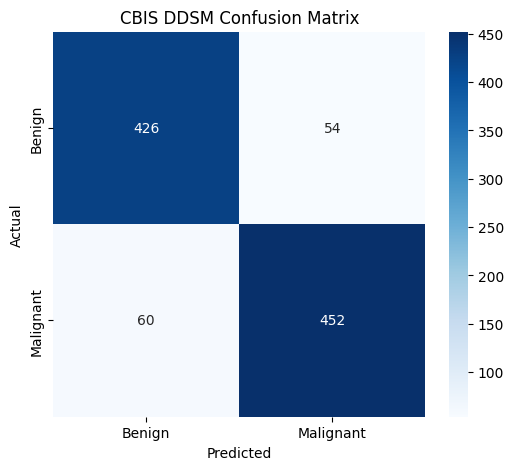

In [52]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_true = []
y_pred = []

for images, labels in validationHOG_original_dataset:
    preds = regularized_HOG.predict(images)
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

# Report
print(classification_report(y_true, y_pred, target_names=['Benign', 'Malignant']))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Benign', 'Malignant'], yticklabels=['Benign', 'Malignant'])
plt.title("CBIS DDSM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


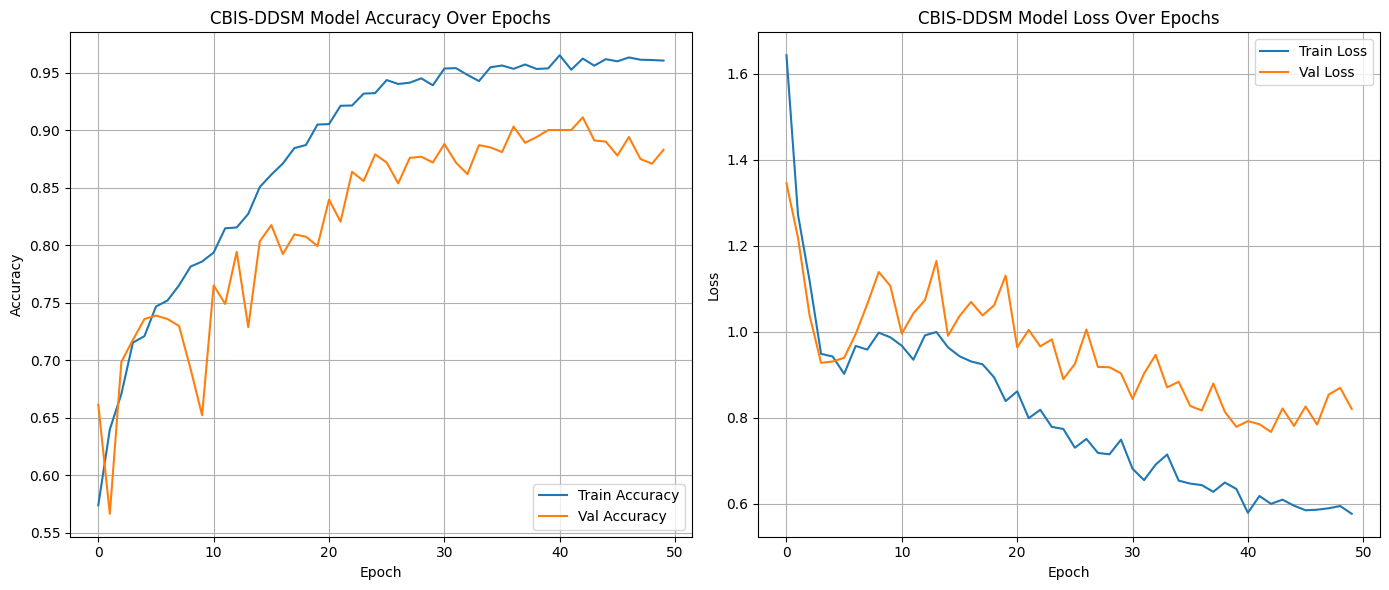

In [53]:
import matplotlib.pyplot as plt

# Extract the history
history = HOG_Model.history

# Plot training & validation accuracy values
plt.figure(figsize=(14, 6))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(history['accuracy'], label='Train Accuracy')
plt.plot(history['val_accuracy'], label='Val Accuracy')
plt.title('CBIS-DDSM Model Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True)

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history['loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Val Loss')
plt.title('CBIS-DDSM Model Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True)

plt.tight_layout()
plt.show()


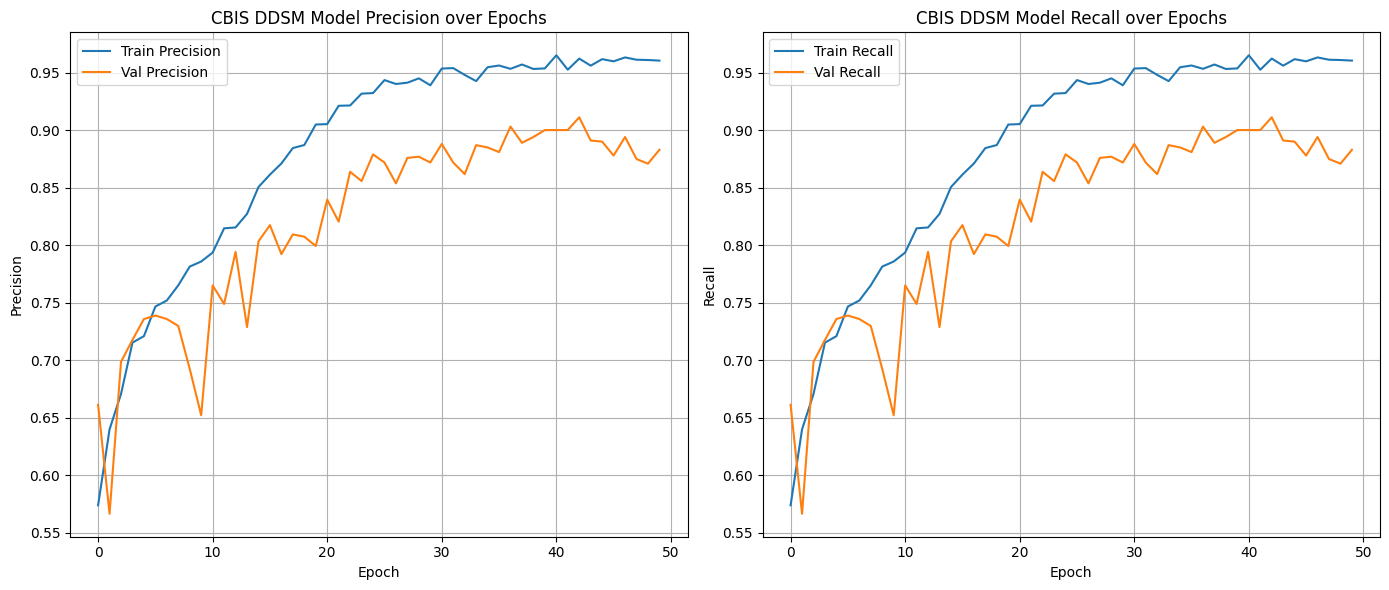

In [54]:
plt.figure(figsize=(14, 6))

# Precision
plt.subplot(1, 2, 1)
plt.plot(history['precision'], label='Train Precision')
plt.plot(history['val_precision'], label='Val Precision')
plt.title('CBIS DDSM Model Precision over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Precision')
plt.legend()
plt.grid(True)

# Recall
plt.subplot(1, 2, 2)
plt.plot(history['recall'], label='Train Recall')
plt.plot(history['val_recall'], label='Val Recall')
plt.title('CBIS DDSM Model Recall over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Recall')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━

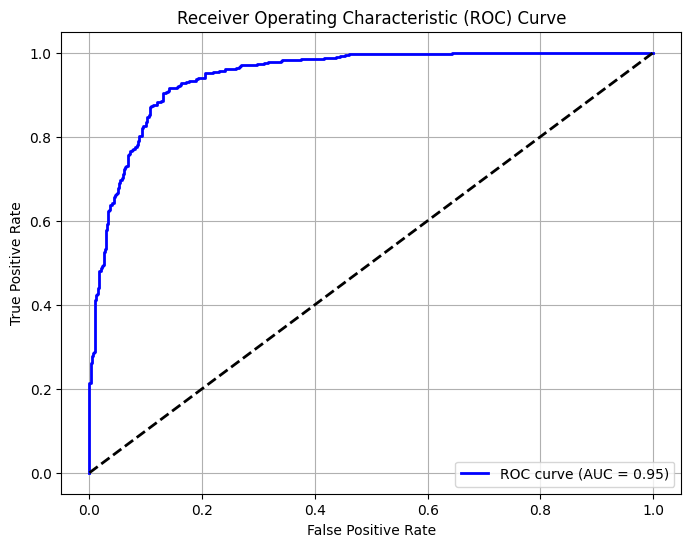

In [55]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

# Step 1: Get true labels and predicted probabilities
y_true = []
y_pred_probs = []

for images, labels in testHOG_original_dataset:
    y_true.extend(np.argmax(labels.numpy(), axis=1))  # Convert one-hot to integer labels
    preds = regularized_HOG.predict(images)
    y_pred_probs.extend(preds[:, 1])  # Probability for class 1 (Malignant)

y_true = np.array(y_true)
y_pred_probs = np.array(y_pred_probs)

# Step 2: Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_true, y_pred_probs)
roc_auc = auc(fpr, tpr)

# Step 3: Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='black', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()


# New Model 

In [56]:
from tensorflow.keras.callbacks import ReduceLROnPlateau

lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    verbose=1,
    min_lr=1e-6
)

In [57]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

In [58]:
def create_improved_cnn(input_shape=(224, 224, 3)):
    model = Sequential()
    model.add(Rescaling(1./255, input_shape=input_shape))  # Proper rescaling
    
    # Conv Block 1
    model.add(Conv2D(32, (3,3), activation='relu', padding='same', 
                    kernel_regularizer=l2(1e-4)))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(2,2))
    model.add(Dropout(0.2))  # Added dropout
    
    # Conv Block 2
    model.add(Conv2D(64, (3,3), activation='relu', padding='same',
                    kernel_regularizer=l2(1e-4)))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(2,2))
    model.add(Dropout(0.3))  # Increased dropout
    
    # Conv Block 3
    model.add(Conv2D(128, (3,3), activation='relu', padding='same',
                    kernel_regularizer=l2(1e-4)))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(2,2))
    model.add(Dropout(0.4))  # Increased dropout
    
    # Flatten & Dense
    model.add(Flatten())
    model.add(Dense(128, activation='relu', kernel_regularizer=l2(1e-4)))
    model.add(BatchNormalization())
    model.add(Dropout(0.5))
    
    model.add(Dense(2, activation='softmax'))
    
    # Use lower learning rate
    optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4)
    
    model.compile(optimizer=optimizer,
                loss='categorical_crossentropy',
                metrics=['accuracy', Precision(), Recall()])
    return model

In [59]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
])

In [60]:
model = create_improved_cnn()

history = model.fit(
    trainHOG_original_dataset,
    validation_data=validationHOG_original_dataset,
    epochs=50,
    batch_size=32,  # Slightly larger batch size
    callbacks=[lr_scheduler, early_stopping]
)

Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/layers/preprocessing/tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


249/249 ━━━━━━━━━━━━━━━━━━━━ 29s 74ms/step - accuracy: 0.5716 - loss: 1.0888 - precision: 0.5716 - recall: 0.5716 - val_accuracy: 0.4808 - val_loss: 10.3022 - val_precision: 0.4808 - val_recall: 0.4808 - learning_rate: 1.0000e-04
Epoch 2/50
249/249 ━━━━━━━━━━━━━━━━━━━━ 17s 69ms/step - accuracy: 0.6175 - loss: 0.8267 - precision: 0.6175 - recall: 0.6175 - val_accuracy: 0.5111 - val_loss: 17.2821 - val_precision: 0.5111 - val_recall: 0.5111 - learning_rate: 1.0000e-04
Epoch 3/50
249/249 ━━━━━━━━━━━━━━━━━━━━ 17s 69ms/step - accuracy: 0.6639 - loss: 0.7310 - precision: 0.6639 - recall: 0.6639 - val_accuracy: 0.5504 - val_loss: 5.0181 - val_precision: 0.5504 - val_recall: 0.5504 - learning_rate: 1.0000e-04
Epoch 4/50
249/249 ━━━━━━━━━━━━━━━━━━━━ 17s 68ms/step - accuracy: 0.6893 - loss: 0.6827 - precision: 0.6893 - recall: 0.6893 - val_accuracy: 0.5363 - val_loss: 3.3952 - val_precision: 0.5363 - val_recall: 0.5363 - learning_rate: 1.0000e-04
Epoch 5/50
249/249 ━━━━━━━━━━━━━━━━━━━━ 17s 68ms/

In [61]:
import numpy as np
from sklearn.metrics import classification_report
from sklearn.preprocessing import LabelBinarizer

# 1. Get true labels from the validation dataset
y_true = []
y_pred = []

# Loop over the batches in validation dataset
for images, labels in validationHOG_original_dataset:
    preds = model.predict(images)
    y_true.extend(np.argmax(labels.numpy(), axis=1))       # Convert one-hot to class index
    y_pred.extend(np.argmax(preds, axis=1))                # Predicted class index

# 2. Define class names
class_names = ['Benign', 'Malignant']

# 3. Generate classification report
report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    digits=3,
    output_dict=True
)

# 4. Pretty print in your desired format
import pandas as pd

# Convert to DataFrame
df_report = pd.DataFrame(report).T

# Reorder and rename rows
df_report = df_report.loc[['Benign', 'Malignant', 'macro avg', 'weighted avg']]
df_report.index = ['Benign', 'Malignant', 'Macro Avg', 'Weighted Avg']

# Round and format
df_report = df_report[['precision', 'recall', 'f1-score', 'support']]
df_report.columns = ['Precision', 'Recall', 'F1-Score', 'Support']
df_report['Support'] = df_report['Support'].astype(int)
df_report = df_report.round(3)

print(df_report)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 540ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━

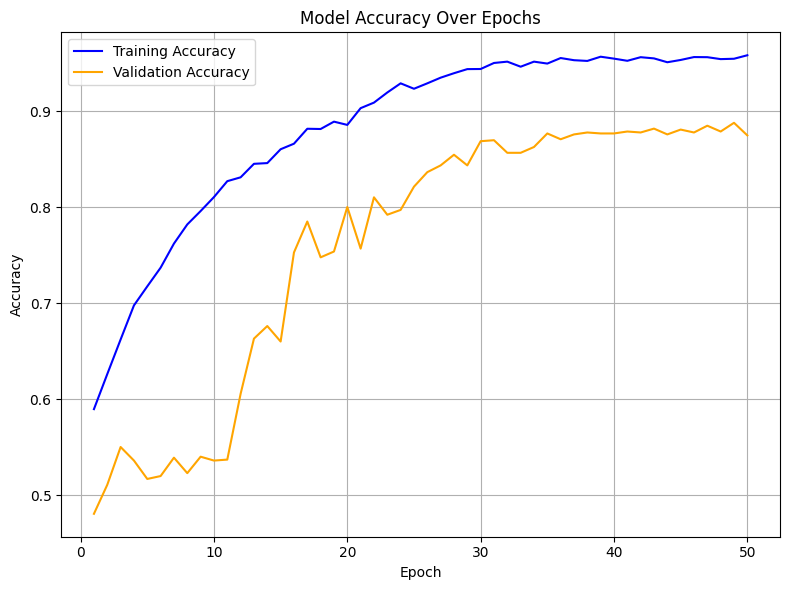

In [62]:
import matplotlib.pyplot as plt

# Extract accuracy from history
train_accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']
epochs = range(1, len(train_accuracy) + 1)

# Plot
plt.figure(figsize=(8, 6))
plt.plot(epochs, train_accuracy, label='Training Accuracy', color='blue')
plt.plot(epochs, val_accuracy, label='Validation Accuracy', color='orange')
plt.title('Model Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [63]:
print("Second Model doesn't perform too well")

Second Model doesn't perform too well


# FIX Initial Model Divergence 

In [64]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dropout, Flatten, Dense, Input, BatchNormalization, Rescaling
from tensorflow.keras.regularizers import l2
from tensorflow.keras.metrics import Precision, Recall
import tensorflow as tf

def create_improved_cnn(input_shape=(224, 224, 3)):
    model = Sequential()
    model.add(Input(shape=input_shape))
    model.add(Rescaling(1./255))  # Enable normalization
    
    # Keep your original filter progression: 32→64→128→256
    model.add(Conv2D(32, (3, 3), activation='relu', padding='same',
                     kernel_regularizer=l2(0.005)))  # Moderate L2
    model.add(BatchNormalization())
    model.add(MaxPooling2D(2, 2))
    
    model.add(Conv2D(64, (3, 3), activation='relu', padding='same',
                     kernel_regularizer=l2(0.005)))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(2, 2))
    
    model.add(Conv2D(128, (3, 3), activation='relu', padding='same',
                     kernel_regularizer=l2(0.005)))
    model.add(BatchNormalization())
    model.add(Dropout(0.2))  # Light dropout only after deeper layers
    model.add(MaxPooling2D(2, 2))
    
    model.add(Conv2D(256, (3, 3), activation='relu', padding='same',
                     kernel_regularizer=l2(0.005)))
    model.add(BatchNormalization())
    model.add(Dropout(0.2))
    model.add(MaxPooling2D(2, 2))
    
    # Dense layers with moderate regularization
    model.add(Flatten())
    model.add(Dense(128, activation='relu', kernel_regularizer=l2(0.005)))
    model.add(BatchNormalization())
    model.add(Dropout(0.3))  # Reduced from 0.5
    
    model.add(Dense(64, activation='relu', kernel_regularizer=l2(0.005)))
    model.add(Dropout(0.3))  # Reduced from 0.5
    
    model.add(Dense(2, activation='softmax'))
    
    return model

# Lighter data augmentation
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),  # Reduced from 0.15
    tf.keras.layers.RandomZoom(0.05),     # Reduced from 0.1
])

def augment_data(images, labels):
    return data_augmentation(images, training=True), labels

# Apply lighter augmentation
trainHOG_original_dataset = trainHOG_original_dataset.map(
    augment_data, num_parallel_calls=tf.data.AUTOTUNE
)

# Learning rate scheduling
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,  # Less aggressive reduction
    patience=7,  # More patience
    min_lr=1e-6,
    verbose=1
)

# Create and compile model
model = create_improved_cnn()

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),  # Back to standard LR
    loss='categorical_crossentropy',
    metrics=['accuracy', Precision(name='precision'), Recall(name='recall')]
)

print("Model Summary:")
model.summary()

# Train the model
history = model.fit(
    trainHOG_original_dataset,
    validation_data=validationHOG_original_dataset,
    epochs=50,
    callbacks=[reduce_lr]
)

Model Summary:


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │     6,422,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴─────────────

 Total params: 6,821,890 (26.02 MB)

 Trainable params: 6,820,674 (26.02 MB)

 Non-trainable params: 1,216 (4.75 KB)

Epoch 1/50
249/249 ━━━━━━━━━━━━━━━━━━━━ 47s 141ms/step - accuracy: 0.5521 - loss: 3.9139 - precision: 0.5521 - recall: 0.5521 - val_accuracy: 0.5181 - val_loss: 3.6476 - val_precision: 0.5181 - val_recall: 0.5181 - learning_rate: 0.0010
Epoch 2/50
249/249 ━━━━━━━━━━━━━━━━━━━━ 34s 135ms/step - accuracy: 0.5955 - loss: 1.6450 - precision: 0.5955 - recall: 0.5955 - val_accuracy: 0.6502 - val_loss: 1.2253 - val_precision: 0.6502 - val_recall: 0.6502 - learning_rate: 0.0010
Epoch 3/50
249/249 ━━━━━━━━━━━━━━━━━━━━ 34s 135ms/step - accuracy: 0.6142 - loss: 1.1799 - precision: 0.6142 - recall: 0.6142 - val_accuracy: 0.6905 - val_loss: 1.2956 - val_precision: 0.6905 - val_recall: 0.6905 - learning_rate: 0.0010
Epoch 4/50
249/249 ━━━━━━━━━━━━━━━━━━━━ 34s 134ms/step - accuracy: 0.6379 - loss: 1.1829 - precision: 0.6379 - recall: 0.6379 - val_accuracy: 0.5403 - val_loss: 1.0802 - val_precision: 0.5403 - val_recall: 0.5403 - learning_rate: 0.0010
Epoch 5/50
249/249 ━━━━━━━━━━━━━━━━━━━━ 34s 134ms/st

# Improved Layer from Initial Model 

In [65]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dropout, Flatten, Dense, Input, BatchNormalization, Rescaling
from tensorflow.keras.regularizers import l2
from tensorflow.keras.metrics import Precision, Recall

def create_regularized_CNN_II(input_shape=(224, 224, 3)):
    model = Sequential()
    model.add(Input(shape=input_shape))

    # # rescaling for a bit 
    # model.add(Input(shape=input_shape)), 
    # Rescaling(1./255),  # Normalize input images to [0, 1]

    # Convolutional blocks with BN + L2
    model.add(Conv2D(32, (3, 3), activation='relu', padding='same',
                     kernel_regularizer=l2(0.001)))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(2, 2))

    model.add(Conv2D(64, (3, 3), activation='relu', padding='same',
                     kernel_regularizer=l2(0.001)))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(2, 2))

    model.add(Conv2D(128, (3, 3), activation='relu', padding='same',
                     kernel_regularizer=l2(0.001)))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(2, 2))

    model.add(Conv2D(256, (3, 3), activation='relu', padding='same',
                     kernel_regularizer=l2(0.001)))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(2, 2))

    # Flatten & Dense
    model.add(Flatten())
    model.add(Dense(128, activation='relu', kernel_regularizer=l2(0.001)))
    model.add(BatchNormalization())
    model.add(Dropout(0.5))

    model.add(Dense(64, activation='relu', kernel_regularizer=l2(0.001)))
    model.add(BatchNormalization())
    model.add(Dropout(0.5))
    
    # Additional layers to combat overfitting
    model.add(Dense(32, activation='relu'))
    model.add(BatchNormalization())
    model.add(Dropout(0.5))
    
    model.add(Dense(16, activation='relu'))
    model.add(BatchNormalization())
    model.add(Dropout(0.5))
    
    # Final output layer
    model.add(Dense(2, activation='softmax'))

    model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy', Precision(name='precision'), Recall(name='recall')])
    return model

In [66]:

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
])

model_II = create_regularized_CNN_II()

history_II = model_II.fit(
    trainHOG_original_dataset,
    validation_data=validationHOG_original_dataset,
    epochs=50,
    batch_size=32,  # Slightly larger batch size
    callbacks=[lr_scheduler, early_stopping]
)


Epoch 1/50
249/249 ━━━━━━━━━━━━━━━━━━━━ 50s 141ms/step - accuracy: 0.5130 - loss: 1.6825 - precision: 0.5130 - recall: 0.5130 - val_accuracy: 0.5323 - val_loss: 1.3802 - val_precision: 0.5323 - val_recall: 0.5323 - learning_rate: 0.0010
Epoch 2/50
249/249 ━━━━━━━━━━━━━━━━━━━━ 34s 135ms/step - accuracy: 0.5132 - loss: 1.3369 - precision: 0.5132 - recall: 0.5132 - val_accuracy: 0.5786 - val_loss: 1.1131 - val_precision: 0.5786 - val_recall: 0.5786 - learning_rate: 0.0010
Epoch 3/50
249/249 ━━━━━━━━━━━━━━━━━━━━ 34s 135ms/step - accuracy: 0.5275 - loss: 1.0959 - precision: 0.5275 - recall: 0.5275 - val_accuracy: 0.5847 - val_loss: 0.9703 - val_precision: 0.5847 - val_recall: 0.5847 - learning_rate: 0.0010
Epoch 4/50
249/249 ━━━━━━━━━━━━━━━━━━━━ 34s 136ms/step - accuracy: 0.5246 - loss: 0.9698 - precision: 0.5246 - recall: 0.5246 - val_accuracy: 0.5101 - val_loss: 0.9180 - val_precision: 0.5101 - val_recall: 0.5101 - learning_rate: 0.0010
Epoch 5/50
249/249 ━━━━━━━━━━━━━━━━━━━━ 34s 134ms/st

# Symmetric CNN

In [67]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dropout, Flatten, Dense, Input, BatchNormalization, Rescaling
from tensorflow.keras.regularizers import l2
from tensorflow.keras.metrics import Precision, Recall

def create_symmetric_cnn(input_shape=(224, 224, 3)):
    model = Sequential()
    model.add(Input(shape=input_shape))
    
    # Encoder (Downsampling)
    model.add(Conv2D(32, (3, 3), activation='relu', padding='same',
                   kernel_regularizer=l2(0.001)))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(2, 2))
    
    model.add(Conv2D(64, (3, 3), activation='relu', padding='same',
                   kernel_regularizer=l2(0.001)))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(2, 2))
    
    model.add(Conv2D(128, (3, 3), activation='relu', padding='same',
                   kernel_regularizer=l2(0.001)))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(2, 2))
    
    model.add(Conv2D(256, (3, 3), activation='relu', padding='same',
                   kernel_regularizer=l2(0.001)))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(2, 2))
    
    # Decoder (Upsampling) - Using Conv2D with stride=1 instead of UpSampling
    model.add(Conv2D(128, (3, 3), activation='relu', padding='same',
                   kernel_regularizer=l2(0.001)))
    model.add(BatchNormalization())
    
    model.add(Conv2D(64, (3, 3), activation='relu', padding='same',
                   kernel_regularizer=l2(0.001)))
    model.add(BatchNormalization())
    
    model.add(Conv2D(32, (3, 3), activation='relu', padding='same',
                   kernel_regularizer=l2(0.001)))
    model.add(BatchNormalization())
    
    # Classifier Head
    model.add(Flatten())
    model.add(Dense(128, activation='relu', kernel_regularizer=l2(0.001)))
    model.add(BatchNormalization())
    model.add(Dropout(0.5))
    
    model.add(Dense(64, activation='relu', kernel_regularizer=l2(0.001)))
    model.add(Dropout(0.5))
    
    model.add(Dense(2, activation='softmax'))
    
    model.compile(optimizer='adam',
                loss='categorical_crossentropy',
                metrics=['accuracy', Precision(name='precision'), Recall(name='recall')])
    return model

In [68]:
symmetric_model = create_symmetric_cnn()

history_symmetric = symmetric_model.fit(
    trainHOG_original_dataset,
    validation_data=validationHOG_original_dataset,
    epochs=50,
    batch_size=32,  # Slightly larger batch size
    callbacks=[lr_scheduler, early_stopping]
)

Epoch 1/50
249/249 ━━━━━━━━━━━━━━━━━━━━ 52s 148ms/step - accuracy: 0.5237 - loss: 2.0929 - precision: 0.5237 - recall: 0.5237 - val_accuracy: 0.4788 - val_loss: 3.9577 - val_precision: 0.4788 - val_recall: 0.4788 - learning_rate: 0.0010
Epoch 2/50
249/249 ━━━━━━━━━━━━━━━━━━━━ 35s 137ms/step - accuracy: 0.5584 - loss: 1.6631 - precision: 0.5584 - recall: 0.5584 - val_accuracy: 0.5706 - val_loss: 1.5205 - val_precision: 0.5706 - val_recall: 0.5706 - learning_rate: 0.0010
Epoch 3/50
249/249 ━━━━━━━━━━━━━━━━━━━━ 34s 136ms/step - accuracy: 0.5813 - loss: 1.4678 - precision: 0.5813 - recall: 0.5813 - val_accuracy: 0.6159 - val_loss: 1.3318 - val_precision: 0.6159 - val_recall: 0.6159 - learning_rate: 0.0010
Epoch 4/50
249/249 ━━━━━━━━━━━━━━━━━━━━ 34s 135ms/step - accuracy: 0.6334 - loss: 1.2896 - precision: 0.6334 - recall: 0.6334 - val_accuracy: 0.6310 - val_loss: 1.2214 - val_precision: 0.6310 - val_recall: 0.6310 - learning_rate: 0.0010
Epoch 5/50
249/249 ━━━━━━━━━━━━━━━━━━━━ 34s 136ms/st